# **Projet — Détection et recatégorisation des lignes mal catégorisées**


## Marketplace e-commerce ameublement

Ce notebook traite un fichier de ventes d'une marketplace e-commerce spécialisée dans l'ameublement.

**Trois objectifs métier :**
1. Identifier les lignes potentiellement mal catégorisées dans la colonne `Nature`
2. Recatégoriser les lignes suspectes **uniquement vers des catégories existantes** (aucune création)
3. Extraire automatiquement les **dimensions** et **couleurs** présentes dans les libellés produits

**Pipeline du projet :**
`Chargement` → `Nettoyage` → `EDA` → `Extraction` → `Tests statistiques` → `Feature Engineering`
→ `Préparation ML` → `Label Noise (cleanlab)` → `Split` → `Modélisation` → `Évaluation`
→ `Détection` → `Recatégorisation` → `Export`

---
**Auteur :** Enzo KOUOKAM  
**Dataset :** `20210614 Ecommerce sales.xlsb`  
**Environnement :** Google Colab (plan gratuit — optimisé RAM)

## **1 - Exploration du dataset**


### **A.Install & import**

In [2]:
# Installation des bibliothèques nécessaires
# --quiet pour ne pas surcharger les logs Colab
!pip install pyxlsb openpyxl scikit-learn cleanlab --quiet

In [3]:
import os
import re
import unicodedata
import warnings
import gc
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, cross_val_predict, StratifiedKFold
)
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from sklearn.preprocessing import LabelEncoder, label_binarize

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 80)

print("Imports OK.")

Imports OK.


In [4]:
# Thème global pour les graphs
sns.set_palette("pastel")

###**B . Chargement & Vue d'ensemble**

### Objectif
Charger le fichier source et obtenir une première vue sur sa structure :
volume, colonnes, types et valeurs manquantes.

In [5]:
# ============================================================
# Chargement du fichier XLSB
# ============================================================
# Adapter FILE_PATH selon votre environnement Colab
# Option A — fichier uploadé dans Colab :
FILE_PATH = "20210614 Ecommerce sales.xlsb"

# Option B — fichier dans Google Drive (décommenter si nécessaire) :
# from google.colab import drive
# drive.mount('/content/drive')
# FILE_PATH = "/content/drive/MyDrive/20210614 Ecommerce sales.xlsb"

SHEET_NAME = "20210614 Ecommerce sales"

print("Chargement du fichier...")
df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME, engine="pyxlsb")

print(f"Fichier chargé : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
display(df.head(3))

Chargement du fichier...
Fichier chargé : 525,034 lignes × 10 colonnes


,Cod_cmd,Libellé produit,Vendeur,Univers,Nature,Date de commande,Montant cmd,Quantité,Prix transport,Délai transport annoncé
0,182210782,Table basse carrée detroit design industriel,Autre vendeur,Canapé Salon Séjour,Table basse,44216,244,4,6.67,10.0
1,182082437,Ours en peluche géant 150 cm brun,Autre vendeur,Enfant Bébé,Peluche,44213,28,1,9.92,10.0
2,182095765,Ours en peluche géant 100 cm blanc,Autre vendeur,Enfant Bébé,Peluche,44214,15,1,9.92,10.0


In [6]:
# Aperçu des colonnes : nom, type, nb valeurs uniques
print("Colonnes disponibles :")
for i, col in enumerate(df.columns, start=1):
    print(f"  {i:02d}. {col}")

print("\nTypes de données :")
print(df.dtypes)

Colonnes disponibles :
  01. Cod_cmd
  02. Libellé produit
  03. Vendeur
  04. Univers
  05. Nature
  06. Date de commande
  07. Montant cmd
  08. Quantité
  09. Prix transport
  10. Délai transport annoncé

Types de données :
Cod_cmd                      int64
Libellé produit             object
Vendeur                     object
Univers                     object
Nature                      object
Date de commande             int64
Montant cmd                  int64
Quantité                     int64
Prix transport             float64
Délai transport annoncé    float64
dtype: object


Colonnes avec valeurs manquantes :


,taux_manquant_%
Délai transport annoncé,45.6
Univers,3.4
Nature,2.2


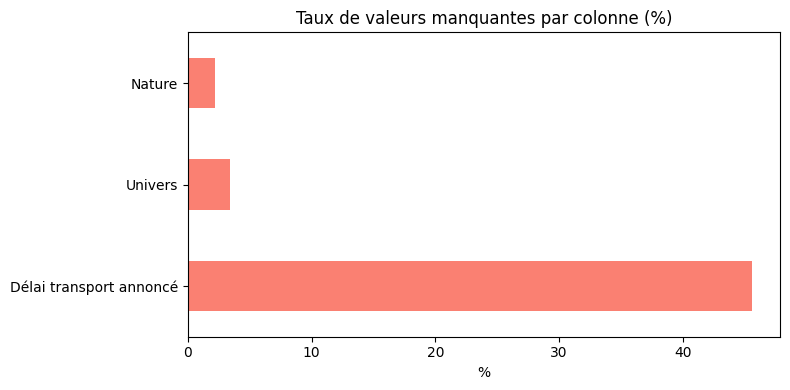

In [7]:
# Taux de valeurs manquantes par colonne
missing = (df.isnull().sum() / len(df) * 100).round(1)
missing = missing[missing > 0].sort_values(ascending=False)

print("Colonnes avec valeurs manquantes :")
display(missing.to_frame("taux_manquant_%"))

plt.figure(figsize=(8, 4))
missing.plot(kind="barh", color="salmon")
plt.title("Taux de valeurs manquantes par colonne (%)")
plt.xlabel("%")
plt.tight_layout()
plt.show()

#### **Interprétation — Chargement et vue d'ensemble**

Le fichier chargé contient **525 034 lignes** et **10 colonnes**, décrivant chacune
une ligne de vente de la marketplace.

**Valeurs manquantes :**
- `délai transport annoncé` : ~45,6 % de valeurs manquantes → colonne trop incomplète
  pour être centrale dans la modélisation.
- `Univers` : ~3,4 % → sera traité par une modalité explicite `"univers_inconnu"`.
- `Nature` : ~2,2 % → **colonne cible** du projet. Ces lignes seront isolées et
  recatégorisées après entraînement du modèle.

**Rôle des colonnes :**

| Colonne | Rôle métier | Usage ML |
|---------|------------|----------|
| Libellé produit | Description texte du produit | Source principale (TF-IDF) |
| Univers | Catégorie macro niveau 1 | Signal contextuel fort |
| Nature | Catégorie fine niveau 2 | **Cible du modèle** |
| Vendeur | Vendeur tiers marketplace | Signal contextuel (à utiliser avec précaution) |
| Montant cmd | Montant commercial | Signal secondaire |
| Quantité | Volume commandé | Signal secondaire |

> **Point méthodologique clé :** si certaines lignes ont déjà une `Nature` incorrecte,
> le modèle apprend sur une vérité terrain bruitée. Cette limite est au cœur du projet
> et sera traitée dans la section **Label Noise**.

### **C . Nettoyage des données**

### Objectif
Transformer le fichier brut en une base exploitable :
- normaliser les noms de colonnes
- supprimer les doublons
- gérer les valeurs manquantes
- convertir les dates
- nettoyer les libellés texte **sans détruire** les formats utiles (dimensions)

In [8]:
# ============================================================
# Normalisation des noms de colonnes
# ============================================================
# Minuscules, sans accents, espaces → underscores

def clean_colname(col):
    col = str(col).strip()
    col = unicodedata.normalize("NFD", col)
    col = "".join(c for c in col if unicodedata.category(c) != "Mn")
    col = col.lower()
    col = re.sub(r"[^a-z0-9]+", "_", col)
    col = col.strip("_")
    return col

data = df.copy()
data.columns = [clean_colname(c) for c in data.columns]

print("Colonnes normalisées :")
print(data.columns.tolist())

Colonnes normalisées :
['cod_cmd', 'libelle_produit', 'vendeur', 'univers', 'nature', 'date_de_commande', 'montant_cmd', 'quantite', 'prix_transport', 'delai_transport_annonce']


In [9]:
# Audit qualité des colonnes avant nettoyage
audit = pd.DataFrame({
    "colonne": data.columns,
    "type": data.dtypes.astype(str),
    "nb_uniques": data.nunique(),
    "manquants_%": (data.isnull().mean() * 100).round(1),
    "exemple": [data[c].dropna().iloc[0] if data[c].notna().any() else "NA"
                for c in data.columns]
})
display(audit)

,colonne,type,nb_uniques,manquants_%,exemple
cod_cmd,cod_cmd,int64,404939,0.0,182210782
libelle_produit,libelle_produit,object,56018,0.0,Table basse carrée detroit design industriel
vendeur,vendeur,object,7,0.0,Autre vendeur
univers,univers,object,10,3.4,Canapé Salon Séjour
nature,nature,object,596,2.2,Table basse
date_de_commande,date_de_commande,int64,90,0.0,44216
montant_cmd,montant_cmd,int64,2151,0.0,244
quantite,quantite,int64,41,0.0,4
prix_transport,prix_transport,float64,544,0.0,6.67
delai_transport_annonce,delai_transport_annonce,float64,74,45.6,10.0


In [10]:
# ============================================================
# Suppression des doublons exacts
# ============================================================
n_before = data.shape[0]
data = data.drop_duplicates()
n_after = data.shape[0]

print(f"Lignes avant suppression des doublons : {n_before:,}")
print(f"Lignes après suppression              : {n_after:,}")
print(f"Doublons supprimés                   : {n_before - n_after:,}")

Lignes avant suppression des doublons : 525,034
Lignes après suppression              : 523,985
Doublons supprimés                   : 1,049


In [11]:
# ============================================================
# Gestion des valeurs manquantes
# ============================================================
# Univers : modalité explicite pour ne pas perdre l'information
if "univers" in data.columns:
    data["univers"] = data["univers"].fillna("Univers_Inconnu")

# Vendeur : chaîne vide (le modèle ignore les tokens vides)
if "vendeur" in data.columns:
    data["vendeur"] = data["vendeur"].fillna("")

# Nature : on NE remplace PAS par "nan" → on garde NaN réel
# Les lignes sans nature seront isolées plus tard dans data_sans_nature
print("Valeurs manquantes après traitement :")
display((data.isnull().sum()[data.isnull().sum() > 0]).to_frame("nb_manquants"))

Valeurs manquantes après traitement :


,nb_manquants
nature,11660
delai_transport_annonce,238783


**Interprétation — Gestion des valeurs manquantes**

- **`univers` manquant** → remplacé par `"Univers_Inconnu"`. Cela permet au modèle de
  recevoir un signal même pour ces lignes, sans inventer de catégorie.
- **`vendeur` manquant** → remplacé par chaîne vide. Le token vendeur disparaît du
  `texte_modele` sans créer d'erreur.
- **`nature` manquante** → conservée comme `NaN` réel. Ces lignes seront **isolées** dans
  `data_sans_nature` et ne participeront **jamais** à l'entraînement du modèle.
  Elles seront recatégorisées après entraînement.

> ⚠️ Ne jamais convertir les `NaN` de `nature` en chaîne `"nan"` — cela créerait une
> fausse catégorie que le modèle apprendrait comme si elle était légitime.

In [12]:
# ============================================================
# Conversion des dates
# ============================================================
if "date_de_commande" in data.columns:
    if pd.api.types.is_numeric_dtype(data["date_de_commande"]):
        # Format Excel serial → datetime
        data["date_de_commande"] = pd.to_datetime(
            data["date_de_commande"], unit="D", origin="1899-12-30", errors="coerce"
        )
    else:
        data["date_de_commande"] = pd.to_datetime(
            data["date_de_commande"], errors="coerce"
        )

    data["annee"]      = data["date_de_commande"].dt.year
    data["mois"]       = data["date_de_commande"].dt.month
    data["jour_semaine"] = data["date_de_commande"].dt.dayofweek

    print("Dates converties. Exemple :")
    display(data[["date_de_commande", "annee", "mois", "jour_semaine"]].head(3))

Dates converties. Exemple :


,date_de_commande,annee,mois,jour_semaine
0,2021-01-20,2021,1,2
1,2021-01-17,2021,1,6
2,2021-01-18,2021,1,0


In [13]:
# ============================================================
# Nettoyage texte des libellés produits
# ============================================================
# IMPORTANT : on conserve les chiffres et les séparateurs (x, *, /, -)
# car ils sont indispensables pour extraire les dimensions plus tard.
# Ex : "Matelas mousse 140x190 cm" doit rester intact pour la regex.

def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text)
    # Normalisation Unicode (suppression des accents)
    text = unicodedata.normalize("NFD", text)
    text = "".join(c for c in text if unicodedata.category(c) != "Mn")
    # Minuscules
    text = text.lower()
    # Conservation : lettres, chiffres, x * / - (pour dimensions)
    text = re.sub(r"[^a-z0-9\s\*\/\-x]", " ", text)
    # Normalisation des espaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

data["libelle_clean"] = data["libelle_produit"].apply(clean_text)

print("Nettoyage texte effectué.")
print(f"  Libellés non vides : {(data['libelle_clean'].str.len() > 0).sum():,}")
display(data[["libelle_produit", "libelle_clean"]].head(5))

Nettoyage texte effectué.
  Libellés non vides : 523,985


,libelle_produit,libelle_clean
0,Table basse carrée detroit design industriel,table basse carree detroit design industriel
1,Ours en peluche géant 150 cm brun,ours en peluche geant 150 cm brun
2,Ours en peluche géant 100 cm blanc,ours en peluche geant 100 cm blanc
3,Lot de 4 chaises mia noires pour salle à manger,lot de 4 chaises mia noires pour salle a manger
4,Meuble tv falko bois blanc et gris,meuble tv falko bois blanc et gris


**Justification du nettoyage texte**

Le nettoyage texte supprime les majuscules et les accents pour uniformiser les libellés.
Il **conserve délibérément** les chiffres et les séparateurs (`x`, `*`, `/`, `-`) car
ils sont indispensables pour l'extraction des dimensions dans la section suivante.

Exemple :
- `Matelas mousse 140x190 cm` → `matelas mousse 140x190 cm` ✓
- Si on avait supprimé les chiffres : `matelas mousse cm` ✗ (dimension perdue)

Cette approche préserve l'information métier dans le texte tout en le normalisant.

In [14]:
# ============================================================
# Suivi des lignes avec / sans Nature
# ============================================================
n_with_nature    = data["nature"].notna().sum()
n_without_nature = data["nature"].isna().sum()

print(f"Lignes avec Nature    : {n_with_nature:,}  ({n_with_nature/len(data)*100:.1f}%)")
print(f"Lignes sans Nature    : {n_without_nature:,} ({n_without_nature/len(data)*100:.1f}%)")
print(f"Natures distinctes    : {data['nature'].nunique()}")

Lignes avec Nature    : 512,325  (97.8%)
Lignes sans Nature    : 11,660 (2.2%)
Natures distinctes    : 596


**Interprétation — Nettoyage des données**

La phase de nettoyage transforme le fichier brut en une base exploitable :

- **{n_before - n_after} doublons supprimés** (lignes identiques sur toutes les colonnes).
- **Colonnes normalisées** : minuscules, sans accents, underscores → évite les erreurs
  d'accès aux colonnes liées à l'encodage.
- **Dates converties** : format Excel sérialisé → datetime Python, avec extraction
  de l'année, du mois et du jour de la semaine pour l'analyse exploratoire.
- **Libellés nettoyés** sans détruire les formats de dimensions.
- **Nature manquante conservée** comme `NaN` réel pour un traitement séparé.

La base nettoyée est maintenant prête pour l'analyse exploratoire.

### **D — Compréhension métier des colonnes**

### Objectif
Relier chaque colonne à sa logique dans la marketplace et identifier son rôle
dans la détection des erreurs de catégorisation.

**Principe de la marketplace :**
- Un site agrège les produits de **vendeurs tiers** (colonne `vendeur`).
- Chaque produit appartient à un **univers** (niveau macro) et une **nature** (niveau fin).
- Les vendeurs saisissent eux-mêmes les catégories → **source principale d'erreurs**.
- La qualité de la catégorisation impacte : recherche produit, navigation, recommandations,
  analyses commerciales et expérience client.

In [15]:
# Analyse des colonnes métier disponibles
colonnes_metier = [c for c in [
    "cod_cmd", "libelle_produit", "vendeur", "univers", "nature",
    "date_de_commande", "montant_cmd", "quantite",
    "prix_transport", "delai_transport_annonce"
] if c in data.columns]

metier_audit = pd.DataFrame({
    "colonne": colonnes_metier,
    "nb_uniques": [data[c].nunique() for c in colonnes_metier],
    "manquants_%": [(data[c].isna().mean() * 100).round(1) for c in colonnes_metier],
    "exemple": [str(data[c].dropna().iloc[0])[:60] if data[c].notna().any()
                else "NA" for c in colonnes_metier]
})
display(metier_audit)

,colonne,nb_uniques,manquants_%,exemple
0,cod_cmd,404939,0.0,182210782
1,libelle_produit,56018,0.0,Table basse carrée detroit design industriel
2,vendeur,7,0.0,Autre vendeur
3,univers,11,0.0,Canapé Salon Séjour
4,nature,596,2.2,Table basse
5,date_de_commande,90,0.0,2021-01-20 00:00:00
6,montant_cmd,2151,0.0,244
7,quantite,41,0.0,4
8,prix_transport,544,0.0,6.67
9,delai_transport_annonce,74,45.6,10.0


In [16]:
print("Natures distinctes :", data["nature"].nunique() if "nature" in data.columns else "Absent")
print("Univers distincts  :", data["univers"].nunique() if "univers" in data.columns else "Absent")
print("Vendeurs distincts :", data["vendeur"].nunique() if "vendeur" in data.columns else "Absent")

Natures distinctes : 596
Univers distincts  : 11
Vendeurs distincts : 7


#### **Point critique — Double rôle de la colonne `Nature`**

La colonne `Nature` joue **deux rôles simultanés** dans ce projet :

1. **Catégorie actuelle** : la valeur telle que saisie par le vendeur dans le système.
2. **Cible du modèle supervisé** : la variable que le modèle doit prédire.

Ce double rôle crée un **biais de confirmation potentiel** :
si le modèle apprend directement sur des natures déjà fausses, il reproduit les erreurs
avec une haute confiance et les valide comme "OK" lors de la détection.

**La solution à ce problème est la section Label Noise (cleanlab)**, qui sera traitée
après la préparation ML. Elle permet d'identifier et d'exclure les lignes mal étiquetées
avant l'entraînement, ce qui rompt ce biais de confirmation.

## **2 — Analyse exploratoire du catalogue (EDA)**

### Objectif
Comprendre la structure, les déséquilibres et les caractéristiques du catalogue avant
de construire le modèle. L'EDA guide les choix de features et les métriques d'évaluation.

In [17]:
# Statistiques descriptives des variables numériques
print("STATISTIQUES DESCRIPTIVES — COLONNES NUMÉRIQUES")
num_cols = ["montant_cmd", "quantite", "prix_transport", "delai_transport_annonce"]
num_cols = [c for c in num_cols if c in data.columns]
display(data[num_cols].describe().round(2))

STATISTIQUES DESCRIPTIVES — COLONNES NUMÉRIQUES


,montant_cmd,quantite,prix_transport,delai_transport_annonce
count,523985.00,523985.00,523985.00,285202.00
mean,238.27,1.11,5.71,11.08
std,274.84,0.72,14.18,13.79
min,15.00,1.00,-16.67,0.00
25%,58.00,1.00,0.00,3.00
50%,156.00,1.00,0.00,8.00
75%,318.00,1.00,0.00,12.00
max,11858.00,208.00,416.67,84.00


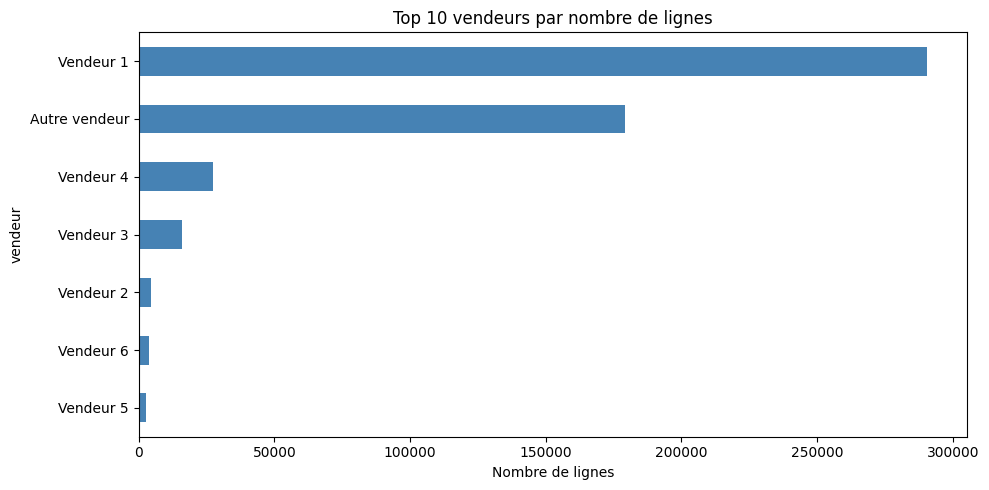

,nb_lignes
vendeur,
Vendeur 1,290639
Autre vendeur,179020
Vendeur 4,27486
Vendeur 3,15978
Vendeur 2,4329
Vendeur 6,3703
Vendeur 5,2830


In [18]:
# Top 10 vendeurs par nombre de lignes
if "vendeur" in data.columns:
    top_vendeurs = data["vendeur"].value_counts().head(10)

    plt.figure(figsize=(10, 5))
    top_vendeurs.sort_values().plot(kind="barh", color="steelblue")
    plt.title("Top 10 vendeurs par nombre de lignes")
    plt.xlabel("Nombre de lignes")
    plt.tight_layout()
    plt.show()

    display(top_vendeurs.to_frame("nb_lignes"))

**Interprétation — Répartition par vendeur**

Le catalogue est dominé par quelques vendeurs qui concentrent une très grande proportion des lignes.
Ce déséquilibre est typique des marketplaces : quelques vendeurs très actifs coexistent avec de
nombreux petits vendeurs.

**Impact sur la modélisation :**
- Un vendeur dominant peut créer un biais si ses produits sont sur-représentés dans
  certaines natures. Le modèle pourrait alors apprendre à associer un vendeur à une nature
  plutôt qu'à lire le libellé produit.
- C'est pourquoi le vendeur est intégré dans `texte_modele` comme un **signal contextuel**,
  mais la source principale reste le libellé produit.

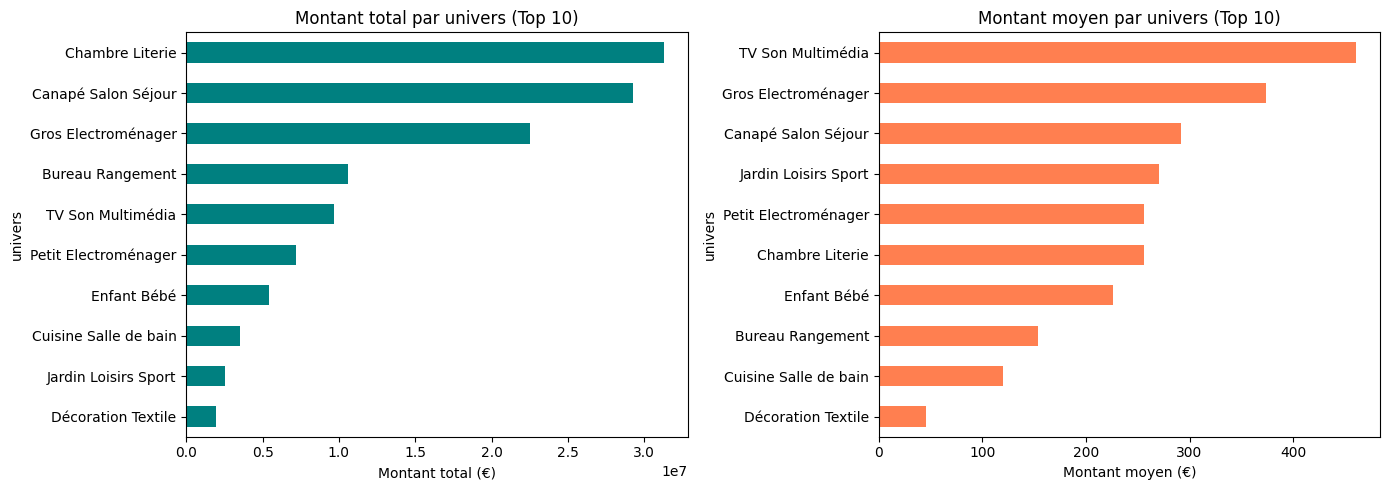

,montant_total,montant_moyen
univers,,
Chambre Literie,31274774,256.39
Canapé Salon Séjour,29255277,291.42
Gros Electroménager,22525633,373.42
Bureau Rangement,10595720,154.06
TV Son Multimédia,9707633,460.84
Petit Electroménager,7213441,256.49
Enfant Bébé,5436188,225.80
Cuisine Salle de bain,3502913,119.72
Jardin Loisirs Sport,2567643,270.79


In [19]:
# Montant total et moyen par univers (top 10)
if "montant_cmd" in data.columns and "univers" in data.columns:
    ca_par_univers = (
        data.groupby("univers")["montant_cmd"]
        .agg(["sum", "mean"])
        .sort_values("sum", ascending=False)
        .head(10)
        .rename(columns={"sum": "montant_total", "mean": "montant_moyen"})
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ca_par_univers["montant_total"].sort_values().plot(
        kind="barh", ax=axes[0], color="teal"
    )
    axes[0].set_title("Montant total par univers (Top 10)")
    axes[0].set_xlabel("Montant total (€)")

    ca_par_univers["montant_moyen"].sort_values().plot(
        kind="barh", ax=axes[1], color="coral"
    )
    axes[1].set_title("Montant moyen par univers (Top 10)")
    axes[1].set_xlabel("Montant moyen (€)")

    plt.tight_layout()
    plt.show()
    display(ca_par_univers.round(2))

**Interprétation — Montant par univers**

Les univers `Chambre Literie`, `Canapé Salon Séjour` et `Gros Électroménager` concentrent
les valeurs commerciales les plus importantes. Cela correspond à des catégories de produits
à prix unitaire élevé.

Le montant commercial est un **signal contextuel utile** mais pas causal : un matelas coûte
plus cher qu'un coussin, mais le montant seul ne suffit pas à catégoriser un produit.
Le signal principal reste le libellé texte.

Quantité médiane : 1.0
Quantité moyenne : 1.11
% de commandes à quantité = 1 : 92.6%


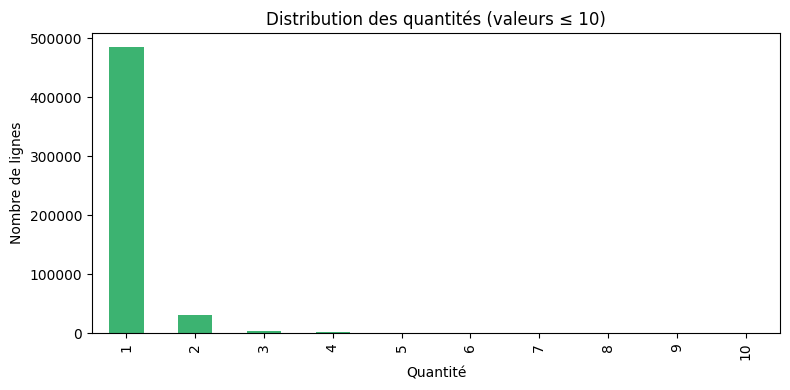

In [20]:
# Distribution des quantités
if "quantite" in data.columns:
    print(f"Quantité médiane : {data['quantite'].median()}")
    print(f"Quantité moyenne : {data['quantite'].mean():.2f}")
    print(f"% de commandes à quantité = 1 : {(data['quantite'] == 1).mean()*100:.1f}%")

    plt.figure(figsize=(8, 4))
    data["quantite"].clip(upper=10).value_counts().sort_index().plot(
        kind="bar", color="mediumseagreen"
    )
    plt.title("Distribution des quantités (valeurs ≤ 10)")
    plt.xlabel("Quantité")
    plt.ylabel("Nombre de lignes")
    plt.tight_layout()
    plt.show()

**Interprétation — Distribution des quantités**

La très grande majorité des commandes porte sur **une seule unité**. Cette distribution
très concentrée confirme que la variable `quantite` a un **faible pouvoir discriminant**
pour la catégorisation : elle ne permet pas de distinguer un matelas d'une chaise.

Elle conserve un intérêt pour l'analyse commerciale, mais ne sera pas une feature centrale
du modèle.

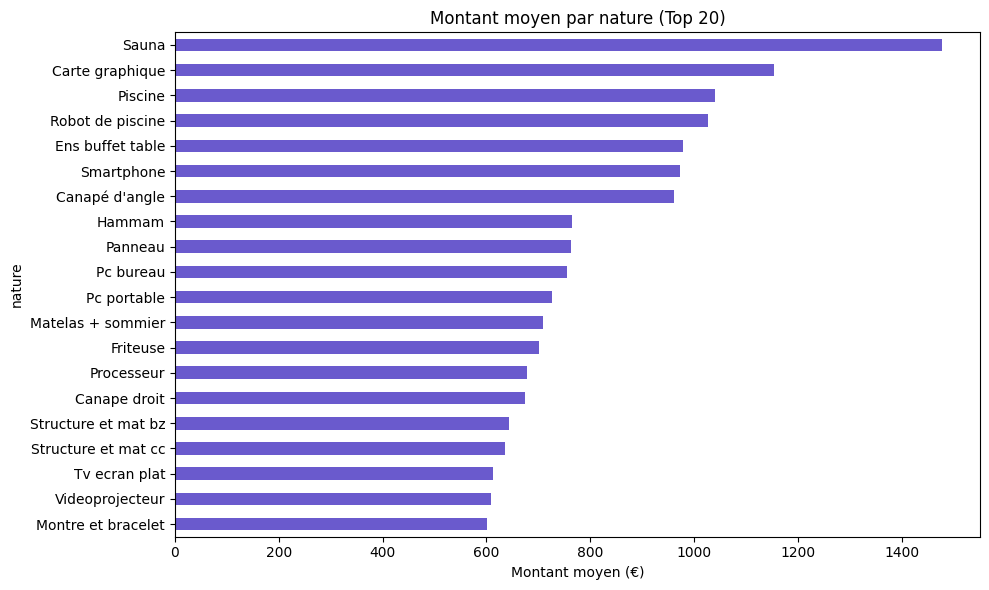

In [21]:
# Montant moyen par nature (top 20)
if "montant_cmd" in data.columns and "nature" in data.columns:
    ca_par_nature = (
        data.groupby("nature")["montant_cmd"]
        .mean()
        .sort_values(ascending=False)
        .head(20)
    )

    plt.figure(figsize=(10, 6))
    ca_par_nature.sort_values().plot(kind="barh", color="slateblue")
    plt.title("Montant moyen par nature (Top 20)")
    plt.xlabel("Montant moyen (€)")
    plt.tight_layout()
    plt.show()

**Interprétation — Montant moyen par nature**

Certaines natures ont des montants moyens élevés (matelas, lits, canapés, électroménager),
tandis que d'autres ont des montants plus faibles (accessoires, textiles, petits meubles).

Cette information enrichit la compréhension métier mais ne constitue pas un signal de
catégorisation fiable : deux natures peuvent avoir des montants proches sans être
sémantiquement proches.

**Conclusion de l'EDA :**
L'analyse exploratoire confirme que le dataset est riche mais déséquilibré :
quelques vendeurs, univers et natures dominent. La catégorisation repose
prioritairement sur le **libellé produit**, enrichi par l'univers et les informations
extraites (dimensions, couleurs).

### **A — Analyse des catégories Univers / Nature**

#### Objectif
Analyser la structure hiérarchique du catalogue (Univers → Nature) et quantifier
les déséquilibres de classes avant de construire le modèle.

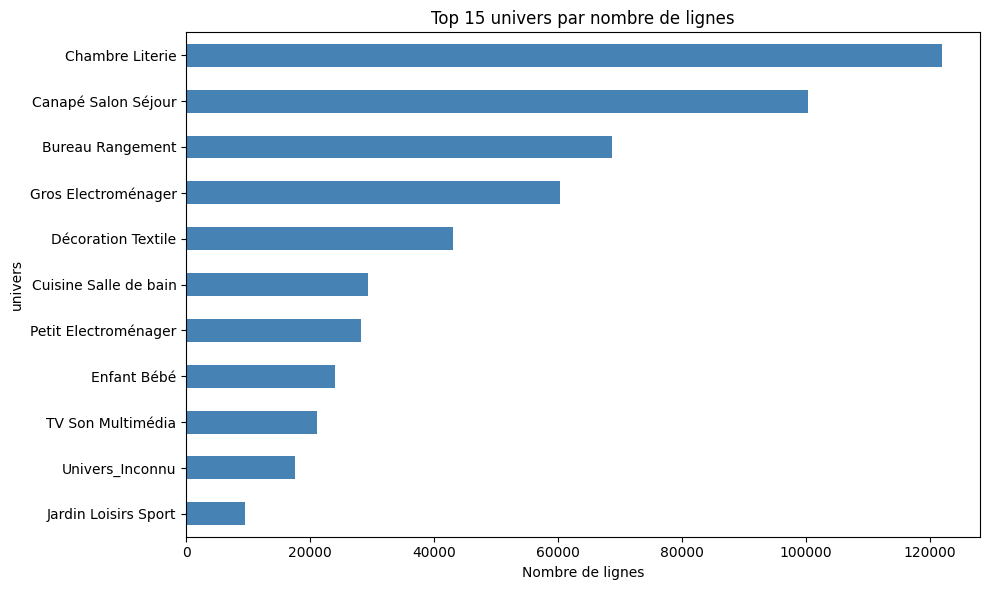

Nombre d'univers distincts : 11


,nb_lignes
univers,
Chambre Literie,121981
Canapé Salon Séjour,100390
Bureau Rangement,68775
Gros Electroménager,60323
Décoration Textile,43019
Cuisine Salle de bain,29259
Petit Electroménager,28124
Enfant Bébé,24075
TV Son Multimédia,21065


In [22]:
# Distribution des univers
if "univers" in data.columns:
    univers_counts = data["univers"].value_counts()

    plt.figure(figsize=(10, 6))
    univers_counts.head(15).sort_values().plot(kind="barh", color="steelblue")
    plt.title("Top 15 univers par nombre de lignes")
    plt.xlabel("Nombre de lignes")
    plt.tight_layout()
    plt.show()

    print(f"Nombre d'univers distincts : {univers_counts.shape[0]}")
    display(univers_counts.head(10).to_frame("nb_lignes"))

**Interprétation — Répartition des univers**

Quelques univers concentrent la grande majorité des lignes (ex. `Chambre Literie`,
`Canapé Salon Séjour`, `Bureau Rangement`). Ce déséquilibre est attendu dans une
marketplace : certaines catégories de produits sont beaucoup plus vendues que d'autres.

Ce déséquilibre **justifie l'utilisation de `class_weight="balanced"`** dans les modèles
et du **F1 macro** comme métrique principale d'évaluation, afin de ne pas masquer les
performances sur les catégories minoritaires.

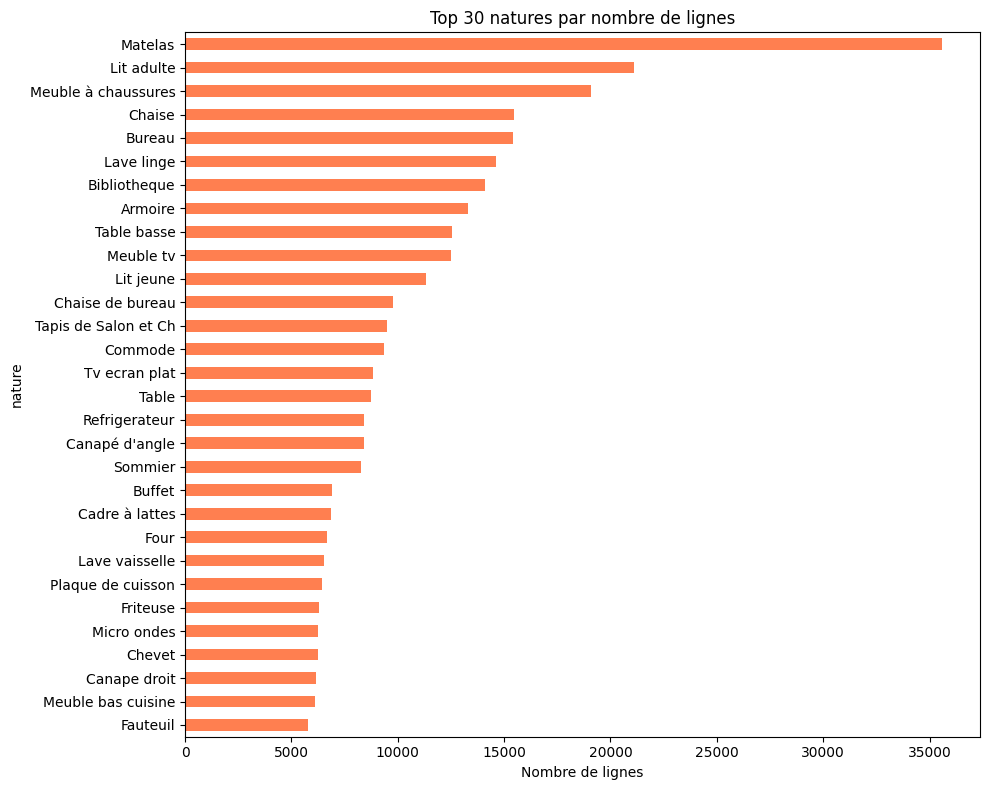

Nombre de natures distinctes : 596


,nb_lignes
nature,
Matelas,35592
Lit adulte,21119
Meuble à chaussures,19105
Chaise,15486
Bureau,15405
Lave linge,14639
Bibliotheque,14080
Armoire,13313
Table basse,12530


In [23]:
# Distribution des natures (top 30)
if "nature" in data.columns:
    nature_counts = data["nature"].value_counts()

    plt.figure(figsize=(10, 8))
    nature_counts.head(30).sort_values().plot(kind="barh", color="coral")
    plt.title("Top 30 natures par nombre de lignes")
    plt.xlabel("Nombre de lignes")
    plt.tight_layout()
    plt.show()

    print(f"Nombre de natures distinctes : {nature_counts.shape[0]}")
    display(nature_counts.head(10).to_frame("nb_lignes"))

**Interprétation — Répartition des natures**

Les natures `Matelas`, `Lit adulte`, `Meuble à chaussures` et `Chaise` dominent le dataset.
La distribution est très déséquilibrée : les 10 premières natures représentent une part
très importante des lignes, tandis que de nombreuses natures sont rares.

**Implication sur la modélisation :**
- Le F1 macro est retenu comme métrique principale car il traite toutes les classes à égalité.
- `class_weight="balanced"` est appliqué dans les modèles pour compenser le déséquilibre.

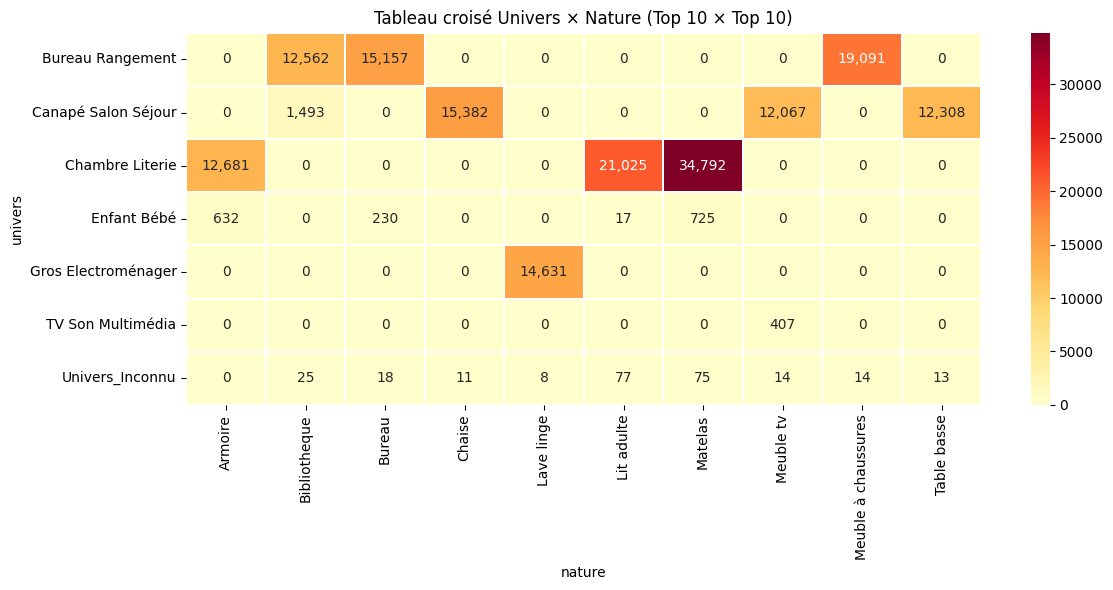

In [24]:
# Tableau croisé Univers × Nature (top 10 × top 10)
if "univers" in data.columns and "nature" in data.columns:
    top_univers = data["univers"].value_counts().head(10).index
    top_natures = data["nature"].value_counts().head(10).index

    cross = pd.crosstab(
        data.loc[data["univers"].isin(top_univers), "univers"],
        data.loc[data["nature"].isin(top_natures), "nature"]
    )

    plt.figure(figsize=(12, 6))
    sns.heatmap(cross, cmap="YlOrRd", fmt=",", annot=True, linewidths=0.3)
    plt.title("Tableau croisé Univers × Nature (Top 10 × Top 10)")
    plt.tight_layout()
    plt.show()

**Interprétation — Tableau croisé Univers / Nature**

Le tableau croisé révèle que **chaque univers contient plusieurs natures** et que
certaines natures appartiennent à plusieurs univers. C'est le signe d'une structure
hiérarchique réelle mais imparfaite dans le catalogue.

Cette ambiguïté est précisément ce qui crée des erreurs de catégorisation :
un vendeur peut hésiter entre deux natures proches et choisir la mauvaise.

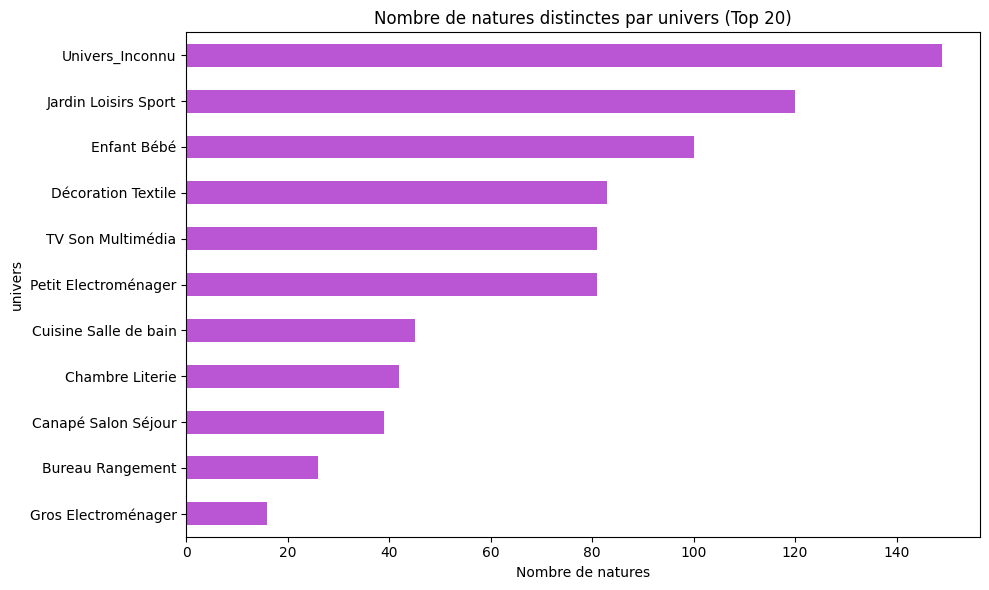

In [25]:
# Nombre de natures différentes par univers
if "univers" in data.columns and "nature" in data.columns:
    nat_par_univers = (
        data.groupby("univers")["nature"]
        .nunique()
        .sort_values(ascending=False)
        .head(20)
    )

    plt.figure(figsize=(10, 6))
    nat_par_univers.sort_values().plot(kind="barh", color="mediumorchid")
    plt.title("Nombre de natures distinctes par univers (Top 20)")
    plt.xlabel("Nombre de natures")
    plt.tight_layout()
    plt.show()

**Interprétation — Natures par univers**

Certains univers sont très hétérogènes (nombreuses natures différentes), ce qui augmente
la difficulté de classification. Un univers avec 30 natures différentes demande au modèle
une discrimination plus fine qu'un univers avec seulement 3 natures.

**Conclusion — Analyse des catégories :**
Le catalogue présente une structure hiérarchique réelle mais déséquilibrée.
La variable `univers` est le signal contextuel le plus fort pour prédire `nature`,
comme le confirmeront les tests statistiques de la section 9.

### **B — Analyse texte des libellés produits**

#### Objectif
Analyser la richesse textuelle des libellés et identifier les mots les plus discriminants
pour la catégorisation. Cette analyse justifie l'utilisation de TF-IDF.

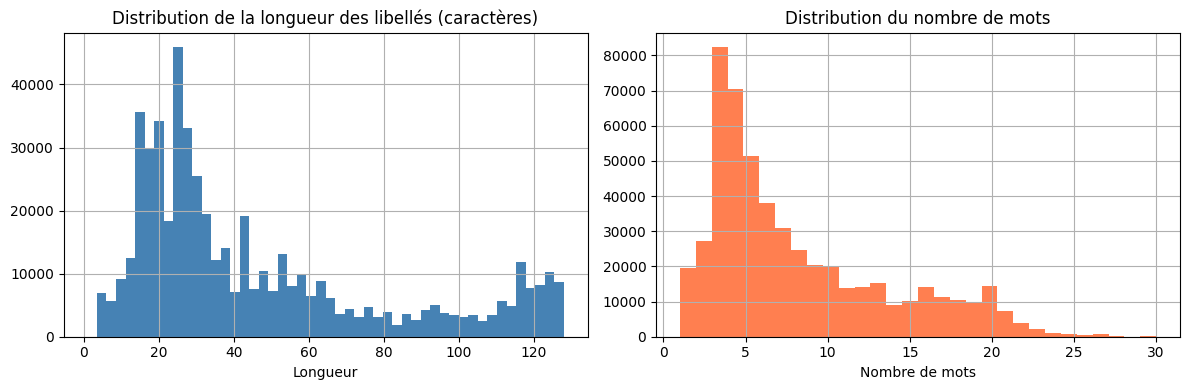

Longueur médiane  : 32 caractères
Nombre de mots médian : 6 mots


In [26]:
# Longueur et nombre de mots des libellés
data["len_libelle"]      = data["libelle_clean"].str.len()
data["nb_mots_libelle"]  = data["libelle_clean"].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

data["len_libelle"].clip(upper=200).hist(bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution de la longueur des libellés (caractères)")
axes[0].set_xlabel("Longueur")

data["nb_mots_libelle"].clip(upper=30).hist(bins=30, ax=axes[1], color="coral")
axes[1].set_title("Distribution du nombre de mots")
axes[1].set_xlabel("Nombre de mots")

plt.tight_layout()
plt.show()

print(f"Longueur médiane  : {data['len_libelle'].median():.0f} caractères")
print(f"Nombre de mots médian : {data['nb_mots_libelle'].median():.0f} mots")

**Interprétation — Longueur et nombre de mots des libellés**

La majorité des libellés sont courts (médiane autour de 3 à 5 mots). Cette brièveté crée
une difficulté pour la classification : un libellé court comme `meuble bois noir` est
ambigu et peut correspondre à plusieurs natures.

C'est pourquoi l'enrichissement via l'univers, la présence de dimensions et de couleurs
est important : il ajoute du contexte au texte seul.

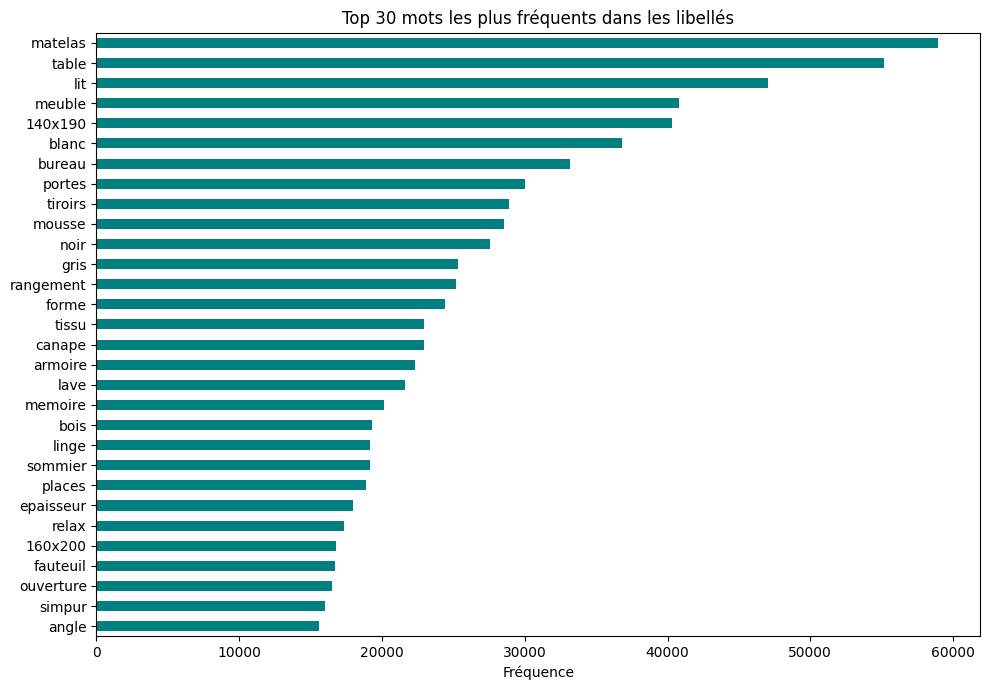

In [27]:
# Top 30 mots les plus fréquents (hors stopwords)
stopwords_fr = set([
    "de", "du", "des", "la", "le", "les", "en", "et", "a", "avec",
    "pour", "un", "une", "lot", "cm", "mm", "par", "sur", "sans",
    "x", "ou", "au", "aux", "se", "son", "sa", "ses", "ce", "cet",
    "cette", "ces", "l", "d", "s", "j", "y", "n", "m", "qu"
])

all_words = []
for libelle in data["libelle_clean"].dropna():
    all_words.extend([
        w for w in libelle.split()
        if w not in stopwords_fr and len(w) > 2
    ])

word_counts = Counter(all_words)
top_words   = pd.Series(dict(word_counts.most_common(30)))

plt.figure(figsize=(10, 7))
top_words.sort_values().plot(kind="barh", color="teal")
plt.title("Top 30 mots les plus fréquents dans les libellés")
plt.xlabel("Fréquence")
plt.tight_layout()
plt.show()

**Interprétation — Mots les plus fréquents**

Les termes `matelas`, `meuble`, `lit`, `table`, `chaise` et `bureau` confirment un signal
textuel fort. Ces mots sont très discriminants pour les catégories correspondantes.

Cependant, des mots comme `bois`, `blanc`, `noir` ou `lot` apparaissent dans de nombreuses
natures différentes. C'est pourquoi une simple recherche par mots-clés serait insuffisante :
**TF-IDF** pondère les mots selon leur pouvoir discriminant réel dans le corpus.

Un mot très fréquent partout (ex. `blanc`) reçoit un poids faible. Un mot rare mais
caractéristique d'une catégorie (ex. `matelas`) reçoit un poids élevé.

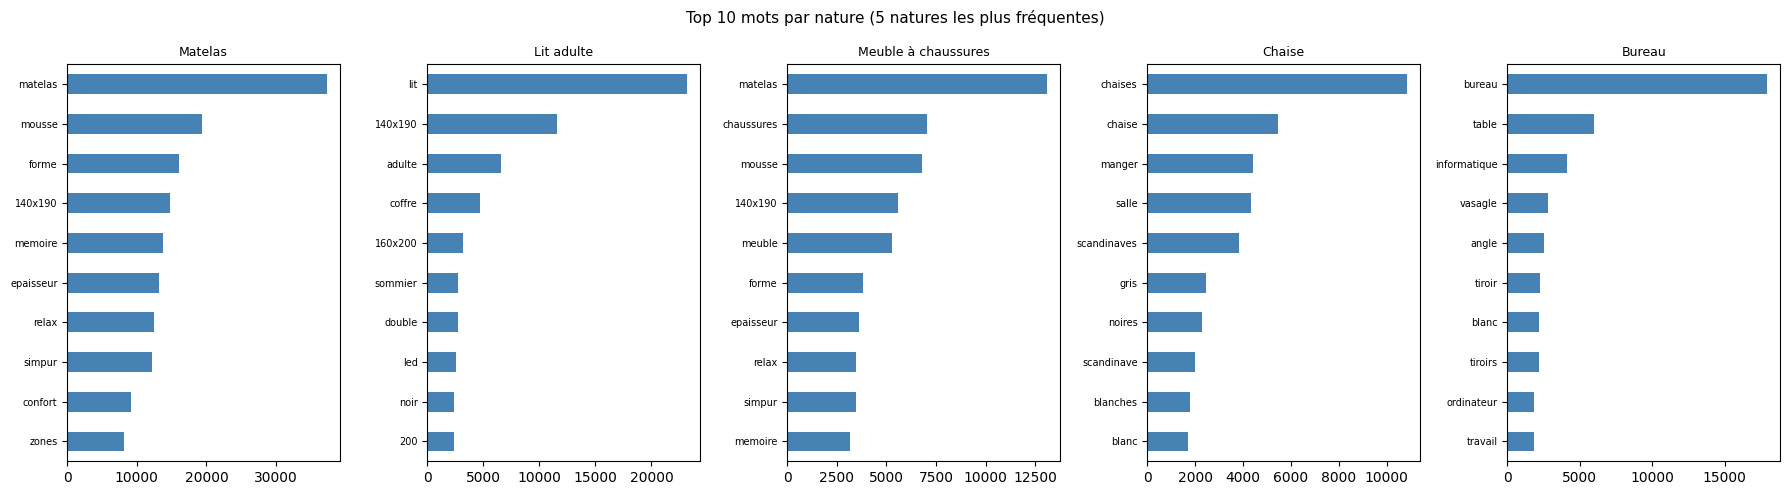

In [28]:
# Mots fréquents par nature (top 5 natures les plus fréquentes)
top_natures = data["nature"].value_counts().head(5).index.tolist()

fig, axes = plt.subplots(1, len(top_natures), figsize=(18, 5))

for idx, nat in enumerate(top_natures):
    subset = data.loc[data["nature"] == nat, "libelle_clean"].dropna()
    words  = []
    for lib in subset:
        words.extend([w for w in lib.split() if w not in stopwords_fr and len(w) > 2])
    top = pd.Series(Counter(words)).nlargest(10)

    top.sort_values().plot(kind="barh", ax=axes[idx], color="steelblue")
    axes[idx].set_title(nat[:25], fontsize=9)
    axes[idx].tick_params(axis="y", labelsize=7)

plt.suptitle("Top 10 mots par nature (5 natures les plus fréquentes)", fontsize=11)
plt.tight_layout()
plt.show()

**Interprétation — Mots fréquents par nature**

L'analyse par nature confirme que chaque grande catégorie est associée à un vocabulaire
caractéristique :
- `Matelas` → termes liés à la literie (mousse, mémoire, ferme, souple...)
- `Meuble à chaussures` → termes liés au rangement chaussures
- `Lit adulte` → termes liés au mobilier de chambre
- `Chaise` → termes liés au mobilier de bureau / cuisine

Ce signal textuel est suffisamment fort pour entraîner un modèle TF-IDF performant.
Les erreurs de catégorisation se produisent principalement sur des libellés courts
ou ambigus dont le vocabulaire chevauche plusieurs natures.

**Conclusion — Analyse texte :**
Les libellés contiennent un signal exploitable pour le Machine Learning. Une représentation
TF-IDF est adaptée car elle pondère les mots selon leur pouvoir discriminant réel.

## **3 — Extraction des DIMENSIONS & COULEURS**

### Objectif
Répondre directement aux consignes du projet :
- **A.** Faire remonter les **dimensions** présentes dans les libellés (ex: `140x190 cm`)
- **B.** Faire remonter les **couleurs/finitions** présentes dans les libellés

Ces extractions produisent des colonnes structurées exploitables par le modèle et
utilisables directement dans l'export final.

### **A. Extraction des dimensions**

### Objectif
Détecter les formats de dimensions dans les libellés produits et les normaliser.

Formats détectés :
- `140x190`, `140 x 190`, `140*190`, `140/190` → `140*190`
- `120x40x75 cm` → `120*40*75` (trois dimensions)
- `140 190 cm` (avec unité explicite) → `140*190`

In [29]:
def extract_dimension(text):
    """
    Extrait une dimension (ex: 140x190, 140*190, 140 190 cm) et
    la normalise avec le séparateur '*'.
    Retourne np.nan si aucune dimension trouvée.
    """
    if pd.isna(text):
        return np.nan

    text_c = clean_text(text)

    # Format avec séparateur explicite : x, *, /, - (2 ou 3 dimensions)
    pattern = (
        r"(?<!\d)(\d{2,4})\s*(?:x|\*|/|-)\s*(\d{2,4})"
        r"(?:\s*(?:x|\*|/|-)\s*(\d{2,4}))?\s*(?:cm|mm|m)?(?!\d)"
    )
    match = re.search(pattern, text_c)
    if match:
        dims = [d for d in match.groups() if d is not None]
        return "*".join(dims)

    # Format avec espaces + unité explicite : "140 190 cm"
    pattern_space = (
        r"(?<!\d)(\d{2,4})\s+(\d{2,4})(?:\s+(\d{2,4}))?\s*(?:cm|mm)(?!\w)"
    )
    match = re.search(pattern_space, text_c)
    if match:
        dims = [d for d in match.groups() if d is not None]
        if all(10 <= int(d) <= 1000 for d in dims):
            return "*".join(dims)

    return np.nan

# Application
data["dimension_extraite"] = data["libelle_produit"].apply(extract_dimension)
data["has_dimension"]      = data["dimension_extraite"].notna().astype(int)

taux_dim = data["has_dimension"].mean() * 100
print(f"Taux de lignes avec dimension détectée : {taux_dim:.2f}%")
display(data[["libelle_produit", "dimension_extraite", "has_dimension"]].dropna(
    subset=["dimension_extraite"]
).head(10))

Taux de lignes avec dimension détectée : 30.06%


,libelle_produit,dimension_extraite,has_dimension
26,Panneau décoratif universel 160x60 cm flower gris,160*60,1
72,Surmatelas mousse mémoire de forme 10 zones 90x190 cm,90*190,1
113,Couette bicolore gris foncé et gris 200x200 cm 300 gr,200*200,1
167,Vasagle étagère de cuisine à 3 étagères étagère de rangement avec plan de tr...,120*60*90,1
168,Vasagle banc de salle à manger rembourré bout de lit siège rembourré rev tem...,108*32,1
178,Meuble tv buffet bas 110 x 40 x 45 cm avec portes coulissantes et 2 étagères...,110*40*45,1
179,Meuble tv buffet bas 110 x 40 x 45 cm avec portes coulissantes et 2 étagères...,110*40*45,1
197,Meuble tv buffet bas 110 x 40 x 45 cm avec portes coulissantes et 2 étagères...,110*40*45,1
198,Meuble tv buffet bas 110 x 40 x 45 cm avec portes coulissantes et 2 étagères...,110*40*45,1
205,Meuble de salle de bain sur pied meuble de rangement armoire à double porte ...,60*30*82,1


**Interprétation — Extraction des dimensions**

Le taux de détection est d'environ **30 %** des libellés.

Ces dimensions correspondent principalement à des produits liés à la literie :
matelas, lits, sommiers, tapis. Les formats les plus fréquents (`140*190`, `160*200`,
`90*190`) correspondent aux tailles standards du marché ameublement.

**Double bénéfice :**
1. Réponse directe à la consigne (faire remonter les dimensions)
2. Signal métier fort pour le modèle : la présence d'une dimension est très corrélée
   à certaines natures (literie, mobilier de rangement)

**Limites :** les dimensions en toutes lettres ou dans des formats non standards
peuvent être manquées. Des faux positifs peuvent apparaître sur des références produits
numériques.

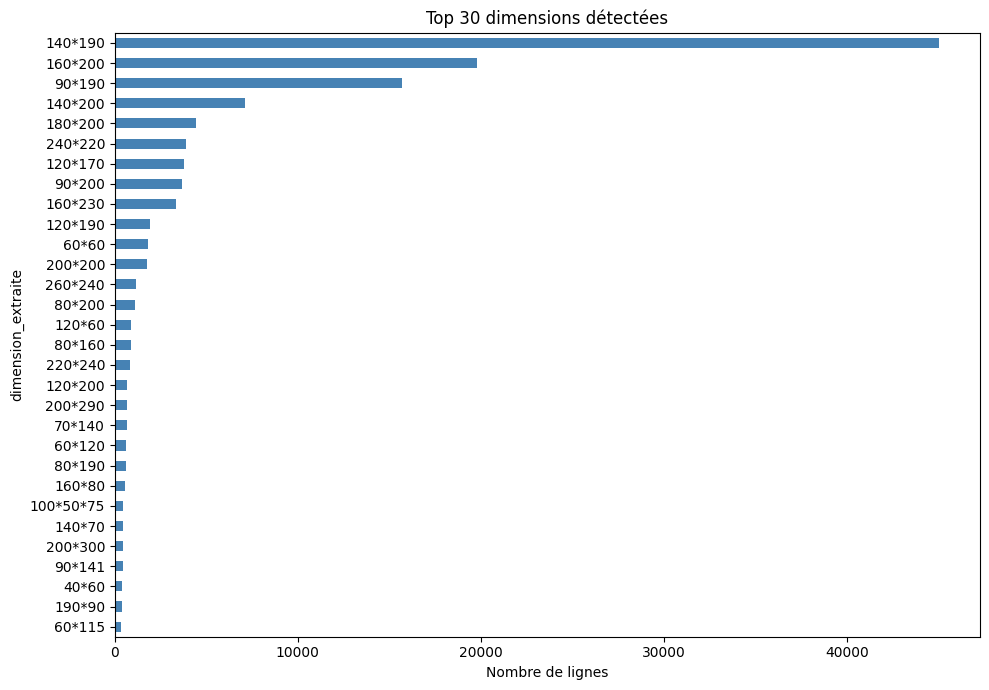

,nb_lignes
dimension_extraite,
140*190,45030
160*200,19808
90*190,15673
140*200,7140
180*200,4433
240*220,3912
120*170,3763
90*200,3669
160*230,3369


In [30]:
# Top 30 dimensions les plus fréquentes
top_dimensions = data["dimension_extraite"].value_counts().head(30)

plt.figure(figsize=(10, 7))
top_dimensions.sort_values().plot(kind="barh", color="steelblue")
plt.title("Top 30 dimensions détectées")
plt.xlabel("Nombre de lignes")
plt.tight_layout()
plt.show()

display(top_dimensions.head(10).to_frame("nb_lignes"))

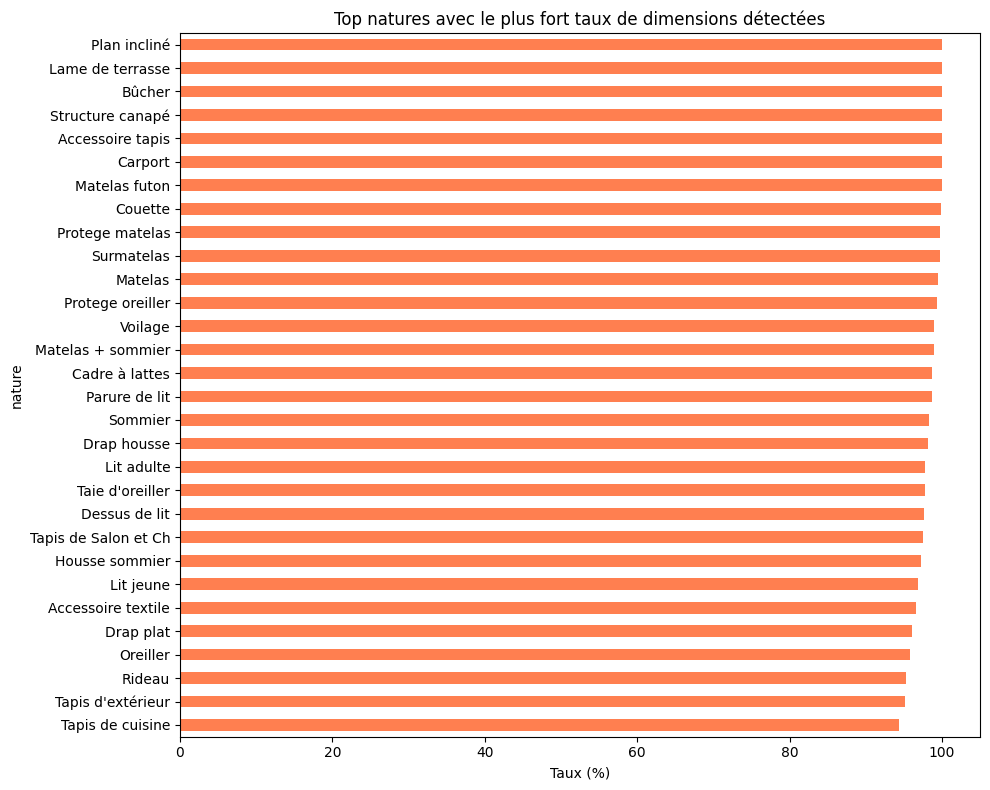

In [31]:
# Natures avec le plus fort taux de dimensions détectées
if "nature" in data.columns:
    dim_by_nature = (
        data.groupby("nature")["has_dimension"]
        .mean()
        .sort_values(ascending=False)
        .head(30) * 100
    )

    plt.figure(figsize=(10, 8))
    dim_by_nature.sort_values().plot(kind="barh", color="coral")
    plt.title("Top natures avec le plus fort taux de dimensions détectées")
    plt.xlabel("Taux (%)")
    plt.tight_layout()
    plt.show()

### **B. Extraction des couleurs**

### Objectif
Détecter les couleurs et finitions présentes dans les libellés à l'aide d'un dictionnaire
de mots-clés adapté à l'ameublement. Certaines finitions matières (bois, chêne, métal)
sont incluses car elles décrivent l'apparence du produit dans ce contexte métier.

In [32]:
# Dictionnaire couleurs / finitions ameublement
color_keywords = {
    "blanc":       ["blanc", "blanche"],
    "noir":        ["noir", "noire"],
    "gris":        ["gris", "grise"],
    "anthracite":  ["anthracite"],
    "beige":       ["beige"],
    "taupe":       ["taupe"],
    "marron":      ["marron", "brun", "brune", "chocolat"],
    "bleu":        ["bleu", "bleue"],
    "rouge":       ["rouge"],
    "vert":        ["vert", "verte"],
    "jaune":       ["jaune"],
    "rose":        ["rose"],
    "violet":      ["violet", "violette"],
    "orange":      ["orange"],
    "naturel":     ["naturel", "naturelle"],
    "bois":        ["bois"],
    "chene":       ["chene", "chene"],
    "pin":         ["pin"],
    "noyer":       ["noyer"],
    "teck":        ["teck"],
    "metal":       ["metal", "metal"],
    "dore":        ["dore", "dore"],
    "argente":     ["argente", "argente"],
    "transparent": ["transparent", "transparente"]
}

# Table de correspondance mot → couleur normalisée
word_to_color = {}
for color, words in color_keywords.items():
    for w in words:
        word_to_color[clean_text(w)] = color

def extract_colors(text):
    if pd.isna(text):
        return np.nan
    tokens = set(clean_text(text).split())
    found = sorted(set(
        word_to_color[t] for t in tokens if t in word_to_color
    ))
    return ", ".join(found) if found else np.nan

data["couleur_extraite"] = data["libelle_produit"].apply(extract_colors)
data["has_couleur"]      = data["couleur_extraite"].notna().astype(int)

taux_couleur = data["has_couleur"].mean() * 100
print(f"Taux de lignes avec couleur détectée : {taux_couleur:.2f}%")
display(data[["libelle_produit", "couleur_extraite", "has_couleur"]].dropna(
    subset=["couleur_extraite"]
).head(10))

Taux de lignes avec couleur détectée : 23.10%


,libelle_produit,couleur_extraite,has_couleur
1,Ours en peluche géant 150 cm brun,marron,1
2,Ours en peluche géant 100 cm blanc,blanc,1
4,Meuble tv falko bois blanc et gris,"blanc, bois, gris",1
5,Meuble tv falko bois blanc et gris,"blanc, bois, gris",1
8,Meuble à chaussures gris 3 portes blanches avec étagère,gris,1
9,Meuble à chaussures gris 3 portes blanches avec étagère,gris,1
10,Meuble à chaussures gris 3 portes blanches avec étagère,gris,1
11,tagère à double position tania bois imitation h tre l 161 cm,bois,1
12,tagère à double position tania bois imitation h tre l 161 cm,bois,1
13,Table à manger georgia 6 personnes blanche et noire 140cm,"blanc, noir",1


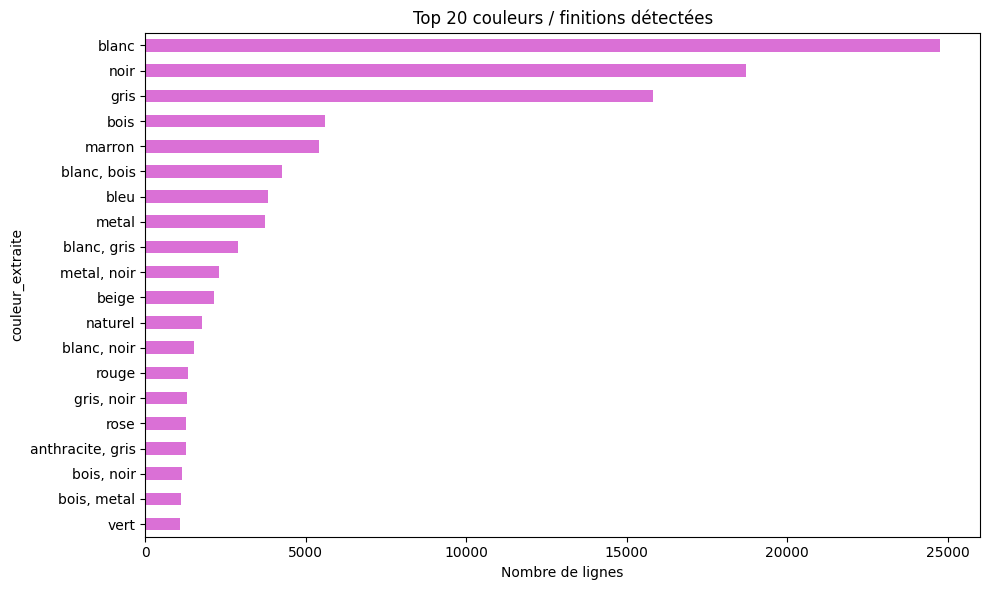

,nb_lignes
couleur_extraite,
blanc,24768
noir,18701
gris,15818
bois,5601
marron,5425
"blanc, bois",4245
bleu,3835
metal,3721
"blanc, gris",2874


In [33]:
# Top 20 couleurs / finitions les plus fréquentes
top_couleurs = data["couleur_extraite"].value_counts().head(20)

plt.figure(figsize=(10, 6))
top_couleurs.sort_values().plot(kind="barh", color="orchid")
plt.title("Top 20 couleurs / finitions détectées")
plt.xlabel("Nombre de lignes")
plt.tight_layout()
plt.show()

display(top_couleurs.head(10).to_frame("nb_lignes"))

In [34]:
# Présence de couleur par univers
if "univers" in data.columns:
    couleur_univers = (
        pd.crosstab(data["univers"], data["has_couleur"], normalize="index") * 100
    ).rename(columns={0: "sans_couleur_%", 1: "avec_couleur_%"})

    display(couleur_univers.sort_values("avec_couleur_%", ascending=False).head(15))

has_couleur,sans_couleur_%,avec_couleur_%
univers,,
Canapé Salon Séjour,57.379221,42.620779
Jardin Loisirs Sport,65.439781,34.560219
Bureau Rangement,70.577972,29.422028
Enfant Bébé,75.792316,24.207684
Décoration Textile,76.184942,23.815058
Cuisine Salle de bain,80.296661,19.703339
Chambre Literie,80.690435,19.309565
Petit Electroménager,83.601195,16.398805
TV Son Multimédia,91.407548,8.592452


**Interprétation — Extraction des couleurs**

Le taux de détection est d'environ **23 %** des libellés. Les couleurs neutres (`blanc`,
`noir`, `gris`) et les finitions bois (`bois`, `chêne`) dominent, ce qui est cohérent
avec un catalogue ameublement.

La présence de couleur varie selon les univers : les univers `Canapé Salon Séjour`,
`Décoration Textile` et `Bureau Rangement` ont les plus forts taux de couleurs détectées.
L'électroménager a un taux faible (les libellés valorisent les caractéristiques techniques).

**Conclusion — Extraction :**
Les deux extractions répondent directement à la consigne et produisent des colonnes
structurées (`dimension_extraite`, `couleur_extraite`, `has_dimension`, `has_couleur`)
utilisées dans l'enrichissement du modèle et dans l'export final.

## **4 — Corrélations & Tests statistiques**

### Objectif
Valider statistiquement l'intérêt des variables avant la modélisation.
Ces tests mesurent les **associations** avec la cible `nature` (sans prouver la causalité).

Tests réalisés :
1. Matrice de corrélation (variables numériques entre elles)
2. Chi-2 (variables catégorielles vs `nature`)
3. V de Cramer (intensité de l'association)
4. Kruskal-Wallis (variables numériques vs `nature`)
5. Mutual Information

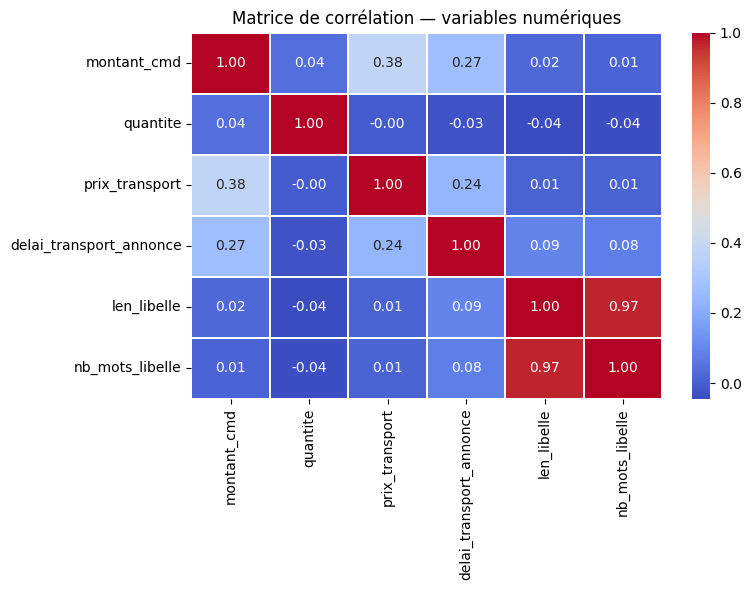

In [35]:
# 1. Matrice de corrélation des variables numériques
variables_num = [
    c for c in ["montant_cmd", "quantite", "prix_transport",
                 "delai_transport_annonce", "len_libelle", "nb_mots_libelle"]
    if c in data.columns
]

if len(variables_num) >= 2:
    corr = data[variables_num].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.3)
    plt.title("Matrice de corrélation — variables numériques")
    plt.tight_layout()
    plt.show()

**Interprétation — Matrice de corrélation**

La corrélation la plus forte (~0,97) est entre `len_libelle` et `nb_mots_libelle`,
ce qui est logique : plus un libellé a de mots, plus il est long en caractères.
Ces deux variables mesurent la même chose → une seule sera retenue dans l'analyse
(mais les deux peuvent coexister sans problème dans le modèle).

Les variables commerciales (`montant_cmd`, `quantite`, `prix_transport`) sont
faiblement corrélées entre elles. La matrice ne peut pas mesurer le lien avec `nature`
(variable catégorielle multi-classes) → nécessité des tests Chi-2 et Kruskal-Wallis.

,Variable,Chi2,p_value
0,univers,4867789.22,0.0
1,vendeur,575013.87,0.0
2,has_dimension,399813.52,0.0
3,has_couleur,112633.74,0.0


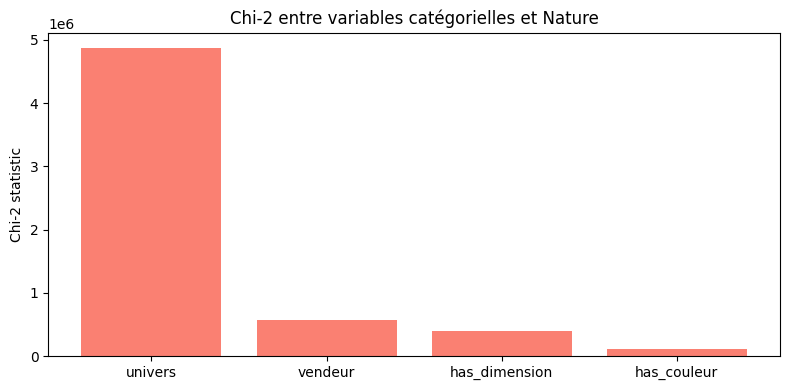

In [36]:
# 2. Chi-2 entre variables catégorielles et Nature
from scipy.stats import chi2_contingency

variables_cat = [c for c in ["univers", "vendeur", "has_dimension", "has_couleur"]
                 if c in data.columns]

resultats_chi2 = []
for var in variables_cat:
    try:
        ct = pd.crosstab(data[var], data["nature"].fillna("NA"))
        chi2, p, dof, _ = chi2_contingency(ct)
        resultats_chi2.append({"Variable": var, "Chi2": round(chi2, 2), "p_value": p})
    except Exception:
        pass

df_chi2 = pd.DataFrame(resultats_chi2).sort_values("Chi2", ascending=False)
display(df_chi2)

plt.figure(figsize=(8, 4))
plt.bar(df_chi2["Variable"], df_chi2["Chi2"], color="salmon")
plt.title("Chi-2 entre variables catégorielles et Nature")
plt.ylabel("Chi-2 statistic")
plt.tight_layout()
plt.show()

,Variable,Cramer_V
0,univers,0.9638
2,has_dimension,0.8735
3,has_couleur,0.4636
1,vendeur,0.4277


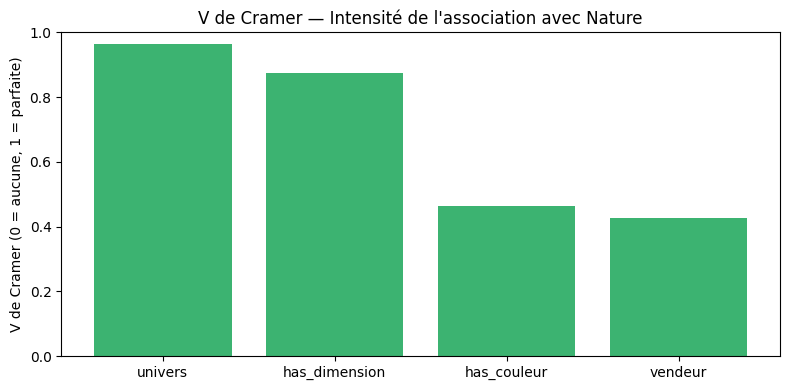

In [37]:
# 3. V de Cramer — intensité de l'association
def cramer_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    phi2 = chi2 / n
    r, k = ct.shape
    return np.sqrt(phi2 / (min(r - 1, k - 1)))

resultats_cramer = []
for var in variables_cat:
    try:
        v = cramer_v(data[var], data["nature"].fillna("NA"))
        resultats_cramer.append({"Variable": var, "Cramer_V": round(v, 4)})
    except Exception:
        pass

df_cramer = pd.DataFrame(resultats_cramer).sort_values("Cramer_V", ascending=False)
display(df_cramer)

plt.figure(figsize=(8, 4))
plt.bar(df_cramer["Variable"], df_cramer["Cramer_V"], color="mediumseagreen")
plt.title("V de Cramer — Intensité de l'association avec Nature")
plt.ylabel("V de Cramer (0 = aucune, 1 = parfaite)")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

**Interprétation — Chi-2 & V de Cramer**

- **Chi-2 :** toutes les p-values sont proches de 0 → l'association avec `nature` existe.
  Avec 500 000 lignes, **la p-value devient quasi automatiquement significative**.
  Elle confirme l'existence de l'association mais pas son intensité.

- **V de Cramer :** mesure réelle de l'intensité de l'association.
  - `univers` : association la plus forte → justifie son intégration dans le modèle
  - `has_dimension` : association forte → signal métier pertinent
  - `has_couleur` : association modérée → utile comme signal complémentaire
  - `vendeur` : association plus faible → signal contextuel à utiliser avec prudence

Ces résultats **valident le Feature Engineering** retenu : `texte_modele` inclura
l'univers et les indicateurs de dimension/couleur comme signaux contextuels.

In [38]:
# 4. Test de Kruskal-Wallis — variables numériques vs Nature
from scipy.stats import kruskal

variables_num_test = [c for c in ["montant_cmd", "quantite", "prix_transport",
                                   "len_libelle", "nb_mots_libelle"]
                      if c in data.columns]

resultats_kruskal = []
natures_sample = data["nature"].dropna().unique()[:50]  # Limite pour la RAM

for var in variables_num_test:
    try:
        groups = [
            data.loc[data["nature"] == n, var].dropna().values
            for n in natures_sample if len(data.loc[data["nature"] == n, var].dropna()) > 0
        ]
        groups = [g for g in groups if len(g) > 0]
        if len(groups) >= 2:
            stat, p = kruskal(*groups)
            resultats_kruskal.append({"Variable": var, "Kruskal_H": round(stat, 2), "p_value": p})
    except Exception:
        pass

df_kruskal = pd.DataFrame(resultats_kruskal).sort_values("Kruskal_H", ascending=False)
display(df_kruskal)

,Variable,Kruskal_H,p_value
0,montant_cmd,72833.21,0.0
3,len_libelle,27438.32,0.0
4,nb_mots_libelle,26842.50,0.0
1,quantite,24806.42,0.0
2,prix_transport,12709.78,0.0


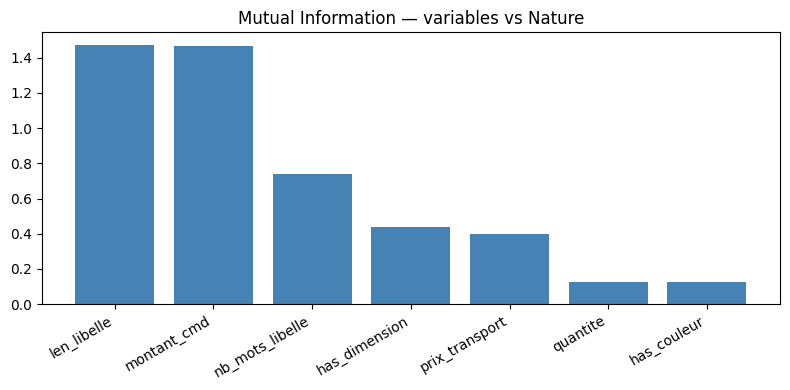

,Variable,MI_Score
3,len_libelle,1.469629
0,montant_cmd,1.467516
4,nb_mots_libelle,0.741384
5,has_dimension,0.436998
2,prix_transport,0.400153
1,quantite,0.126890
6,has_couleur,0.125057


3593

In [39]:
# 5. Mutual Information — variables numériques vs Nature
from sklearn.feature_selection import mutual_info_classif

variables_mi = [c for c in ["montant_cmd", "quantite", "prix_transport",
                              "len_libelle", "nb_mots_libelle", "has_dimension", "has_couleur"]
                if c in data.columns]

# Échantillon pour éviter la saturation RAM
sample_mi = data[variables_mi + ["nature"]].dropna(subset=["nature"]).sample(
    n=min(50000, len(data)), random_state=42
)

X_mi = sample_mi[variables_mi].fillna(0)
y_mi = sample_mi["nature"]

mi_scores = mutual_info_classif(X_mi, y_mi, discrete_features=[False]*len(variables_mi))
df_mi = pd.DataFrame({"Variable": variables_mi, "MI_Score": mi_scores}).sort_values(
    "MI_Score", ascending=False
)

plt.figure(figsize=(8, 4))
plt.bar(df_mi["Variable"], df_mi["MI_Score"], color="steelblue")
plt.title("Mutual Information — variables vs Nature")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

display(df_mi)

del sample_mi, X_mi, y_mi
gc.collect()

**Conclusion — Corrélations et tests statistiques**

Les tests valident la stratégie de Feature Engineering :

| Variable | Association avec Nature | Décision |
|----------|------------------------|----------|
| `univers` | Très forte (Cramer V élevé) | Intégré dans `texte_modele` |
| `has_dimension` | Forte | Intégré dans `texte_modele` |
| `len_libelle` | Modérée (MI) | Utilisé comme signal contextuel |
| `has_couleur` | Modérée | Intégré dans `texte_modele` |
| `vendeur` | Faible | Intégré avec précaution |
| `montant_cmd` | Faible | Non utilisé directement |

La modélisation sera fondée principalement sur les **libellés produits** (TF-IDF)
enrichis par **l'univers** et les **indicateurs dimension/couleur**.

## **5 — Feature Engineering**

### Objectif
Construire la variable finale `texte_modele` utilisée comme entrée du modèle TF-IDF.
Elle combine le libellé nettoyé et les informations contextuelles validées par les tests
statistiques.

**Récapitulatif des features créées :**

| Feature | Rôle | Créée en section |
|---------|------|-----------------|
| `libelle_clean` | Libellé normalisé | 3 |
| `len_libelle` | Longueur texte | 7 |
| `nb_mots_libelle` | Nb mots | 7 |
| `dimension_extraite` | Dimension détectée | 8 |
| `couleur_extraite` | Couleur/finition | 8 |
| `has_dimension` | Indicateur binaire | 8 |
| `has_couleur` | Indicateur binaire | 8 |
| `texte_modele` | **Entrée TF-IDF** | **10** |

In [40]:
# ============================================================
# Construction de texte_modele sur data (dataset complet)
# ============================================================
# texte_modele est créé sur data entier car il sera hérité
# par ml_data et data_sans_nature lors du filtrage en section 11.

data["texte_modele"] = (
    data["libelle_clean"].fillna("") +
    " univers_" + data["univers"].fillna("univers_inconnu").apply(clean_text) +
    " vendeur_" + data["vendeur"].fillna("").apply(clean_text) +
    " dimension_" + data["has_dimension"].astype(str) +
    " couleur_" + data["has_couleur"].astype(str)
)

print("texte_modele construit.")
print(f"Longueur médiane de texte_modele : {data['texte_modele'].str.len().median():.0f} caractères")

display(data[[
    "libelle_produit", "univers", "has_dimension", "has_couleur", "texte_modele"
]].head(5))

texte_modele construit.
Longueur médiane de texte_modele : 100 caractères


,libelle_produit,univers,has_dimension,has_couleur,texte_modele
0,Table basse carrée detroit design industriel,Canapé Salon Séjour,0,0,table basse carree detroit design industriel univers_canape salon sejour ven...
1,Ours en peluche géant 150 cm brun,Enfant Bébé,0,1,ours en peluche geant 150 cm brun univers_enfant bebe vendeur_autre vendeur ...
2,Ours en peluche géant 100 cm blanc,Enfant Bébé,0,1,ours en peluche geant 100 cm blanc univers_enfant bebe vendeur_autre vendeur...
3,Lot de 4 chaises mia noires pour salle à manger,Canapé Salon Séjour,0,0,lot de 4 chaises mia noires pour salle a manger univers_canape salon sejour ...
4,Meuble tv falko bois blanc et gris,Canapé Salon Séjour,0,1,meuble tv falko bois blanc et gris univers_canape salon sejour vendeur_autre...


### **Interprétation — Feature Engineering**

La variable `texte_modele` est l'entrée principale du modèle TF-IDF. Elle combine :

- **Le libellé nettoyé** : signal textuel principal
- **L'univers** sous forme de token (`univers_chambre_literie`) : signal contextuel fort
- **Le vendeur** sous forme de token (`vendeur_xxx`) : signal contextuel à utiliser avec précaution
- **`dimension_True/False`** : signal métier discriminant pour la literie et le mobilier
- **`couleur_True/False`** : signal complémentaire pour le mobilier et la décoration

**Pourquoi encoder univers et vendeur comme tokens texte ?**

En les ajoutant directement dans la chaîne textuelle, TF-IDF les traite comme des mots
supplémentaires et apprend leur association avec les natures. C'est plus efficace et
économe en RAM qu'un encodage one-hot sur 500+ vendeurs.

### **Conclusion — Feature Engineering**

Toutes les features sont maintenant créées sur `data`. Les étapes suivantes filtreront
ce dataset pour séparer les lignes avec `nature` connue (entraînement) et les lignes
sans `nature` (recatégorisation future).

## **6 — Préparation ML**

### Objectif
Séparer le dataset en deux sous-ensembles clairs avant tout entraînement :

- `ml_data` : lignes avec `nature` connue → entraînement et évaluation
- `data_sans_nature` : lignes sans `nature` → recatégorisation après entraînement

Retirer également les classes trop rares pour garantir un split stratifié correct.

> **Logique ML fondamentale :** un modèle supervisé **ne peut jamais** apprendre
> sur des lignes dont la cible est inconnue. La séparation ici est donc non négociable.

In [41]:
# ============================================================
# Création de ml_data et data_sans_nature
# ============================================================

ml_data = data[
    data["nature"].notna() &
    (data["libelle_clean"].str.len() > 0)
].copy()

data_sans_nature = data[
    data["nature"].isna() &
    (data["libelle_clean"].str.len() > 0)
].copy()

print(f"ml_data (avec nature)         : {ml_data.shape[0]:,} lignes")
print(f"data_sans_nature (sans nature): {data_sans_nature.shape[0]:,} lignes")
print(f"Natures distinctes dans ml_data: {ml_data['nature'].nunique()}")

# Vérification : texte_modele est bien présent (hérité de data)
assert "texte_modele" in ml_data.columns, "texte_modele absent — exécuter section 10."
print("texte_modele présent dans ml_data")

ml_data (avec nature)         : 512,325 lignes
data_sans_nature (sans nature): 11,660 lignes
Natures distinctes dans ml_data: 596
texte_modele présent dans ml_data. ✓


In [42]:
# ============================================================
# Retrait des classes trop rares pour le split stratifié
# ============================================================
# Un split stratifié exige >= 2 lignes par classe.
# Les classes ultra-rares sont retirées uniquement de ml_eval
# (base d'évaluation), PAS du dataset métier complet ml_data.

class_counts = ml_data["nature"].value_counts()
rare_classes  = class_counts[class_counts < 2].index

print(f"Classes rares (< 2 lignes) exclues de l'évaluation : {len(rare_classes)}")

ml_eval = ml_data[~ml_data["nature"].isin(rare_classes)].copy()

print(f"ml_eval (base d'évaluation) : {ml_eval.shape[0]:,} lignes")
print(f"Natures dans ml_eval        : {ml_eval['nature'].nunique()}")

Classes rares (< 2 lignes) exclues de l'évaluation : 21
ml_eval (base d'évaluation) : 512,304 lignes
Natures dans ml_eval        : 575


**Conclusion — Préparation ML**

| Ensemble | Volume | Usage |
|----------|--------|-------|
| `data` | ~523 985 lignes | Base complète nettoyée |
| `ml_data` | ~512 325 lignes | Lignes avec nature connue |
| `data_sans_nature` | ~11 660 lignes | Recatégorisation après train |
| `ml_eval` | ~512 314 lignes | Évaluation (classes rares retirées) |

**Prochaine étape critique :** détection et nettoyage du label noise (section 12).
Sans cette étape, le modèle serait entraîné sur une vérité terrain potentiellement
bruitée et reproduirait les erreurs avec haute confiance.

### **A — Détection et nettoyage du Label Noise (cleanlab)**

#### Objectif et justification métier

**Le problème fondamental de ce projet :**
La colonne `nature` est saisie par des vendeurs tiers. Des erreurs existent à grande
échelle : un matelas peut être catégorisé "Meuble à chaussures" par erreur.

**Si on ignore le label noise — biais de confirmation :**
1. Le modèle apprend sur les données bruitées
2. Il apprend l'association erronée "matelas → Meuble à chaussures"
3. Lors de la détection : il prédit "Meuble à chaussures" pour ces matelas
4. `nature_predite == nature` → statut "OK" → **les 12 000 erreurs passent invisibles**

**La solution — Confident Learning (cleanlab) :**
1. **Cross-validation 3 folds** : chaque ligne reçoit une probabilité calculée par un
   modèle qui ne l'a **jamais vue** pendant son entraînement (out-of-fold probabilities)
2. **`cleanlab.find_label_issues`** : identifie les lignes dont la probabilité attribuée
   à leur étiquette actuelle est anormalement faible
3. **`masque_propre`** : ces lignes sont exclues du train → le modèle final apprend
   sur une vérité terrain propre

**Résultat attendu :** le modèle prédit correctement "Matelas" pour les produits
mal étiquetés → statut "Recatégorisation proposée" → les erreurs remontent correctement.

> **RAM Colab (gratuit) :** TF-IDF limité à 5 000 features pour la cross-val
> (suffisant pour cleanlab, pas besoin de la précision du modèle final).
> `n_jobs=1` pour éviter la saturation mémoire multi-process.
> Durée estimée : **5 à 15 minutes**.

In [43]:
# ============================================================================
# Étape 0 —  ÉCHANTILLONNAGE STRATIFIÉ pour cleanlab (évite les 2h d'exécution)
# ============================================================================
#IMPORTANT : PAS de reset_index — on conserve les index originaux
# RAM Colab : max_features=5000 est suffisant pour cleanlab.
# ngram_range=(1,1) divise par ~3 la taille de la matrice par rapport à (1,2).
print("Étape 1 — Vectorisation TF-IDF légère...")

SAMPLE_SIZE = 80_000

print(f"Création de l'échantillon stratifié ({SAMPLE_SIZE:,} lignes)...")

ml_eval_sample = (
    ml_eval
    .groupby("nature", group_keys=False)
    .apply(lambda x: x.sample(
        min(len(x), max(2, int(round(len(x) / len(ml_eval) * SAMPLE_SIZE)))),
        random_state=42
    ))
    .sample(frac=1, random_state=42)
    # PAS de reset_index ici — on garde les index originaux de ml_eval
)

# Retrait des classes avec < 3 lignes (besoin de 3 folds)
counts_sample = ml_eval_sample["nature"].value_counts()
rares_sample  = counts_sample[counts_sample < 3].index
if len(rares_sample) > 0:
    print(f"  Classes retirées (< 3 lignes) : {len(rares_sample)}")
    ml_eval_sample = ml_eval_sample[~ml_eval_sample["nature"].isin(rares_sample)]

print(f"Échantillon final : {ml_eval_sample.shape[0]:,} lignes | {ml_eval_sample['nature'].nunique()} natures")
print(f"Index min/max de l'échantillon : {ml_eval_sample.index.min()} / {ml_eval_sample.index.max()}")
print(f"Index min/max de ml_eval       : {ml_eval.index.min()} / {ml_eval.index.max()}")

Étape 1 — Vectorisation TF-IDF légère...
Création de l'échantillon stratifié (80,000 lignes)...
  Classes retirées (< 3 lignes) : 139
Échantillon final : 79,821 lignes | 436 natures
Index min/max de l'échantillon : 0 / 525024
Index min/max de ml_eval       : 0 / 525033


In [44]:
# ============================================================
# Étape 1 — Vectorisation TF-IDF légère sur l'échantillon
# ============================================================
print("Étape 1 — Vectorisation TF-IDF légère...")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

tfidf_cv = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=5,
    max_df=0.95,
    max_features=5000,
    sublinear_tf=True
)

X_cv     = tfidf_cv.fit_transform(ml_eval_sample["texte_modele"])
le_cv    = LabelEncoder()
y_cv_enc = le_cv.fit_transform(ml_eval_sample["nature"].values)

print(f"Matrice TF-IDF : {X_cv.shape[0]:,} lignes × {X_cv.shape[1]:,} features")
print(f"Natures encodées : {len(le_cv.classes_)}")


Étape 1 — Vectorisation TF-IDF légère...
Matrice TF-IDF : 79,821 lignes × 4,463 features
Natures encodées : 436


In [45]:
# ============================================================
# Étape 2 — Cross-validation out-of-fold (3 folds)
# ============================================================
# Chaque ligne reçoit une probabilité calculée par un modèle
# qui ne l'a JAMAIS vue pendant l'entraînement.
# RAM Colab : n_jobs=1 obligatoire (multi-process sature la RAM).
# solver='saga' est rapide et stable pour les grands datasets.

print("\nÉtape 2 — Cross-validation 3 folds (out-of-fold probas)...")
print("Durée estimée : 5 à 10 min...")

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedKFold

modele_cv = LogisticRegression(
    max_iter=200,
    class_weight="balanced",
    solver="lbfgs",
    C=1.0,
    n_jobs=1
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

y_proba_cv = cross_val_predict(
    modele_cv, X_cv, y_cv_enc,
    cv=cv,
    method="predict_proba",
    n_jobs=1
)

print(f"Probabilités calculées : {y_proba_cv.shape}")
print("Cross-validation terminée. ✓")


Étape 2 — Cross-validation 3 folds (out-of-fold probas)...
Durée estimée : 5 à 10 min...
Probabilités calculées : (79821, 436)
Cross-validation terminée. ✓


Étape 3 — Détection des label issues...

Lignes suspectes identifiées    : 47 (0.06% de l'échantillon)
Lignes propres conservées train : 512,257
RAM libérée. ✓


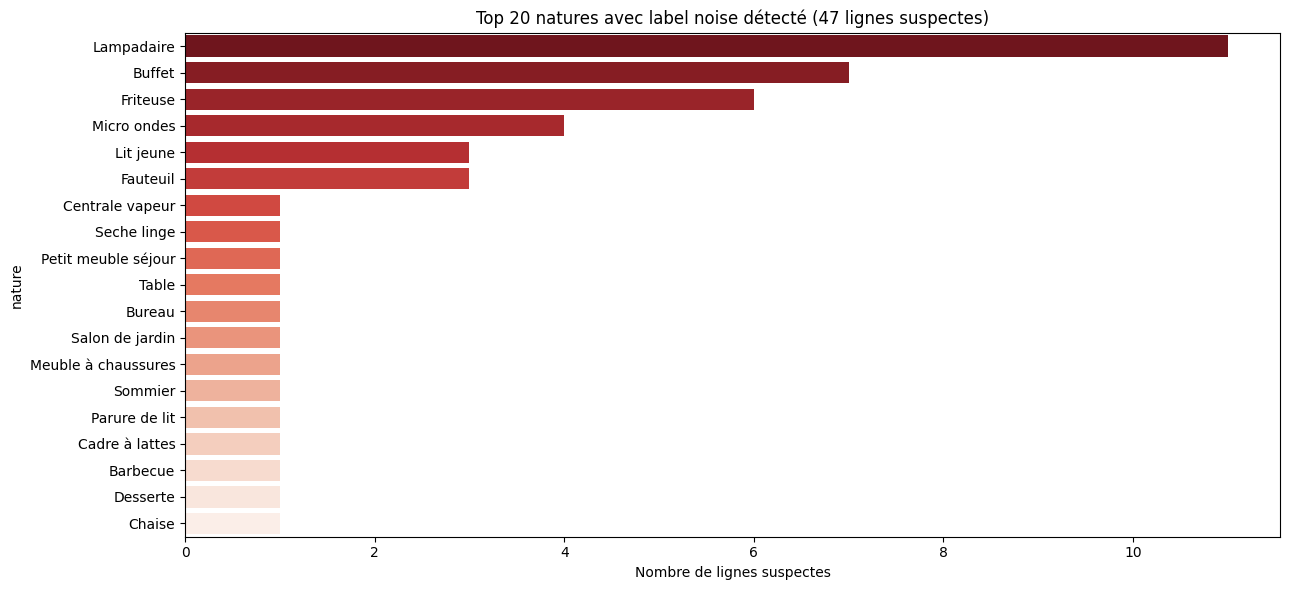


Exemples de lignes suspectes (score le plus faible = plus suspect) :


,libelle_produit,univers,nature,score_label_noise
524669,Coffre pouf table pliable l 38 cm noir,Canapé Salon Séjour,Fauteuil,0.001830
385033,Lot de 4 chaises scandinaves chaises design chaises de salle à manger chaise...,Canapé Salon Séjour,Fauteuil,0.001967
396306,Lot de 4 chaises scandinaves chaises design chaises de salle à manger chaise...,Canapé Salon Séjour,Fauteuil,0.002329
462216,Chaise,Jardin Loisirs Sport,Chaise,0.003296
339698,Mécanisme de banquette bz,Chambre Literie,Sommier,0.006434
231232,Table rectangulaire,Jardin Loisirs Sport,Table,0.006873
260254,Vidaxl mobilier à d ner d extérieur pliable 5 pcs bois d acacia solide,Jardin Loisirs Sport,Salon de jardin,0.007867
163675,Schneider smw20vmb,Gros Electroménager,Micro ondes,0.008243
160714,Chauffe frites inox poste de salage à poser casselin,Petit Electroménager,Friteuse,0.009976
34570,Fer à repasser vapeur,Petit Electroménager,Centrale vapeur,0.010055


In [46]:
# ============================================================
# Étape 3 — Détection du label noise avec cleanlab
# ============================================================
from cleanlab.filter import find_label_issues

print("Étape 3 — Détection des label issues...")

label_issues_idx_relative = find_label_issues(
    labels=y_cv_enc,
    pred_probs=y_proba_cv,
    return_indices_ranked_by="self_confidence",
    frac_noise=0.05
)

# Les index de ml_eval_sample sont les vrais index de ml_eval
# (pas de reset_index dans la cellule 0)
original_indices_sample       = ml_eval_sample.index.values         # vrais index ml_eval
label_issues_indices_original = original_indices_sample[label_issues_idx_relative]

n_issues   = len(label_issues_indices_original)
pct_issues = n_issues / len(original_indices_sample) * 100

# Scores de confiance (1 score par ligne de l'échantillon)
self_conf_scores = y_proba_cv[np.arange(len(y_cv_enc)), y_cv_enc]

# ----------------------------------------------------------
# Propagation dans ml_eval via .loc avec les vrais index
# Lignes hors échantillon → score=1.0 (propres par défaut)
# ----------------------------------------------------------
ml_eval = ml_eval.copy()
ml_eval["score_label_noise"] = 1.0    # défaut = propre
ml_eval["est_propre"]        = True   # défaut = propre

# Injection uniquement sur les lignes de l'échantillon
ml_eval.loc[original_indices_sample, "score_label_noise"] = self_conf_scores
ml_eval.loc[label_issues_indices_original, "est_propre"]  = False

# Masque final : True = propre, False = suspect
masque_propre = ml_eval["est_propre"].values

print(f"\nLignes suspectes identifiées    : {n_issues:,} ({pct_issues:.2f}% de l'échantillon)")
print(f"Lignes propres conservées train : {masque_propre.sum():,}")

# ----------------------------------------------------------
# Libération RAM
# ----------------------------------------------------------
del X_cv, tfidf_cv, modele_cv, y_proba_cv, self_conf_scores
gc.collect()
print("RAM libérée. ✓")

# ----------------------------------------------------------
# Visualisation
# ----------------------------------------------------------
natures_issues = ml_eval[~masque_propre]["nature"].value_counts().head(20)

plt.figure(figsize=(13, 6))
sns.barplot(x=natures_issues.values, y=natures_issues.index, palette="Reds_r")
plt.title(f"Top 20 natures avec label noise détecté ({n_issues:,} lignes suspectes)")
plt.xlabel("Nombre de lignes suspectes")
plt.tight_layout()
plt.show()

print("\nExemples de lignes suspectes (score le plus faible = plus suspect) :")
display(
    ml_eval[~masque_propre][
        ["libelle_produit", "univers", "nature", "score_label_noise"]
    ].sort_values("score_label_noise").head(15)
)

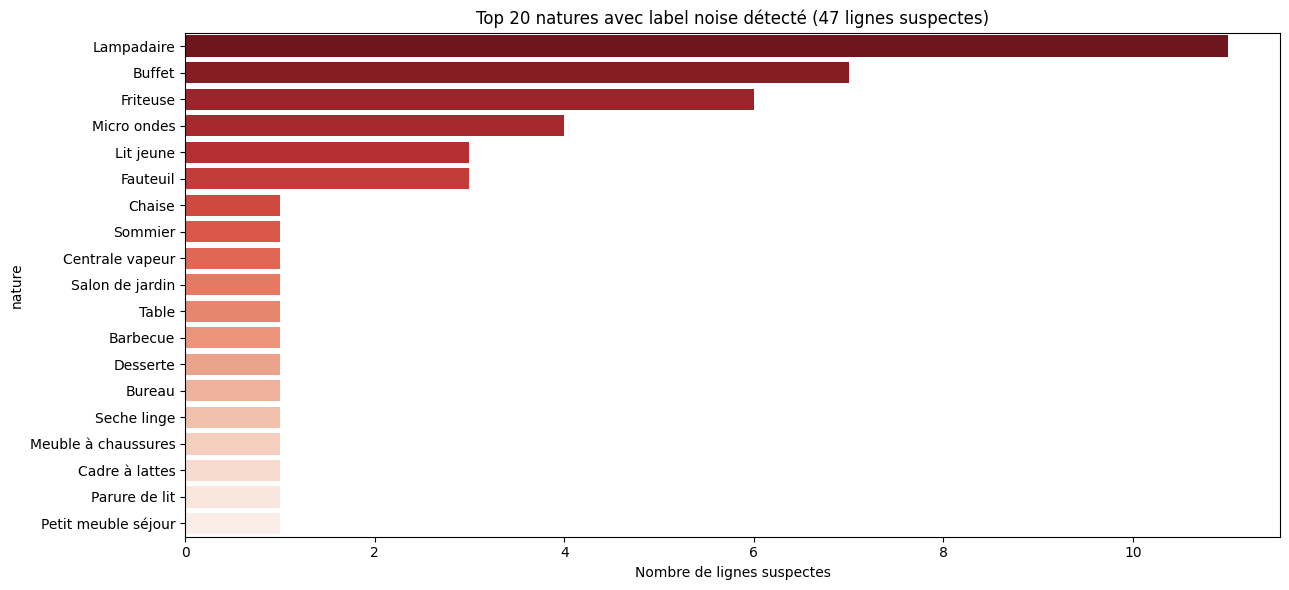


Exemples de lignes suspectes (score le plus faible = plus suspect) :


,libelle_produit,univers,nature,score_label_noise
524669,Coffre pouf table pliable l 38 cm noir,Canapé Salon Séjour,Fauteuil,0.001830
385033,Lot de 4 chaises scandinaves chaises design chaises de salle à manger chaise...,Canapé Salon Séjour,Fauteuil,0.001967
396306,Lot de 4 chaises scandinaves chaises design chaises de salle à manger chaise...,Canapé Salon Séjour,Fauteuil,0.002329
462216,Chaise,Jardin Loisirs Sport,Chaise,0.003296
339698,Mécanisme de banquette bz,Chambre Literie,Sommier,0.006434
231232,Table rectangulaire,Jardin Loisirs Sport,Table,0.006873
260254,Vidaxl mobilier à d ner d extérieur pliable 5 pcs bois d acacia solide,Jardin Loisirs Sport,Salon de jardin,0.007867
163675,Schneider smw20vmb,Gros Electroménager,Micro ondes,0.008243
160714,Chauffe frites inox poste de salage à poser casselin,Petit Electroménager,Friteuse,0.009976
34570,Fer à repasser vapeur,Petit Electroménager,Centrale vapeur,0.010055


In [47]:
# ============================================================
# Visualisation — Natures avec le plus de label noise
# ============================================================

# Correction : on utilise label_issues_indices_original et .loc au lieu de .iloc
natures_issues = ml_eval.loc[label_issues_indices_original, "nature"].value_counts().head(20)

plt.figure(figsize=(13, 6))
sns.barplot(x=natures_issues.values, y=natures_issues.index, palette="Reds_r")
plt.title(f"Top 20 natures avec label noise détecté ({n_issues:,} lignes suspectes)")
plt.xlabel("Nombre de lignes suspectes")
plt.tight_layout()
plt.show()

print("\nExemples de lignes suspectes (score le plus faible = plus suspect) :")
display(
    ml_eval.loc[label_issues_indices_original][
        ["libelle_produit", "univers", "nature", "score_label_noise"]
    ].sort_values("score_label_noise").head(15)
)

**Interprétation — Résultats du nettoyage du Label Noise**

**Ce que montre le graphique :**
Les natures avec le plus de label noise sont souvent celles qui :
- ont un volume important (plus de lignes = plus d'erreurs absolues)
- sont sémantiquement proches d'autres natures (ambiguïté vendeur)
- reçoivent des produits très divers de vendeurs différents

**Lecture du `score_label_noise` :**
Un score proche de 0 signifie que le modèle attribue une probabilité quasi nulle
à l'étiquette actuelle. C'est le signe que le libellé est clairement incohérent
avec sa nature déclarée.

**Exemple concret :**
Un libellé `"Matelas mousse mémoire de forme 140x190 cm"` catégorisé `"Meuble à chaussures"`
reçoit un `score_label_noise` proche de 0 → cleanlab l'identifie comme suspect → il est
exclu du train via `masque_propre`.

**Impact sur la qualité du modèle :**
En excluant ces lignes du train, le modèle final apprend une vérité terrain nettoyée.
Il prédit correctement "Matelas" pour ces produits lors de la détection, ce qui permet
de les identifier comme "Recatégorisation proposée" plutôt que de les valider à tort.

### **B — Split Train / Test**

### Objectif
Séparer les données **nettoyées du label noise** en ensemble d'entraînement et
ensemble de test.

> **Point méthodologique clé :** le split est réalisé **après** application du masque
> `masque_propre`. On entraîne **uniquement sur les lignes validées par cleanlab**.

> Sans cette étape de nettoyage préalable, le modèle apprendrait les erreurs
> de catégorisation et les reproduirait avec haute confiance.

In [48]:
# ============================================================
# Application du masque et split stratifié
# ============================================================
# On filtre ml_eval avec masque_propre pour ne garder
# que les lignes dont cleanlab a validé l'étiquette.

ml_propre = ml_eval[masque_propre].copy()

# Retrait des classes devenues trop rares après nettoyage
counts_propre      = ml_propre["nature"].value_counts()
rares_post_clean   = counts_propre[counts_propre < 2].index
if len(rares_post_clean) > 0:
    print(f"Classes devenues rares après nettoyage : {len(rares_post_clean)}")
    ml_propre = ml_propre[~ml_propre["nature"].isin(rares_post_clean)]

print(f"Lignes propres pour le split : {ml_propre.shape[0]:,}")
print(f"Natures disponibles          : {ml_propre['nature'].nunique()}")

# Split stratifié 80/20
X_train, X_test, y_train, y_test = train_test_split(
    ml_propre["texte_modele"],
    ml_propre["nature"],
    test_size=0.20,
    random_state=42,
    stratify=ml_propre["nature"]
)

print(f"\nTrain : {len(X_train):,} lignes")
print(f"Test  : {len(X_test):,} lignes")
print(f"Ratio test : {len(X_test)/(len(X_train)+len(X_test))*100:.1f}%")

Lignes propres pour le split : 512,257
Natures disponibles          : 575

Train : 409,805 lignes
Test  : 102,452 lignes
Ratio test : 20.0%


In [49]:
# Vérification du split
print("Vérifications de sécurité :")
print(f"  Nature manquante y_train : {pd.Series(y_train).isna().sum()}")
print(f"  Nature manquante y_test  : {pd.Series(y_test).isna().sum()}")

# Vérification qu'aucune classe 'nan' n'a été créée
nan_train = [c for c in y_train.unique() if str(c).lower() == "nan"]
nan_test  = [c for c in y_test.unique()  if str(c).lower() == "nan"]
print(f"  Classes 'nan' y_train : {nan_train if nan_train else 'Aucune ✓'}")
print(f"  Classes 'nan' y_test  : {nan_test  if nan_test  else 'Aucune ✓'}")

# Comparaison des distributions train/test (top 10 natures)
dist = pd.DataFrame({
    "train_%": y_train.value_counts(normalize=True).mul(100).round(2),
    "test_%":  y_test.value_counts(normalize=True).mul(100).round(2)
}).fillna(0)
print("\nDistribution train/test (top 10 natures) :")
display(dist.head(10))

Vérifications de sécurité :
  Nature manquante y_train : 0
  Nature manquante y_test  : 0
  Classes 'nan' y_train : Aucune ✓
  Classes 'nan' y_test  : Aucune ✓

Distribution train/test (top 10 natures) :


,train_%,test_%
nature,,
ASSIST TEL PAYANTE,0.00,0.00
Abat jour,0.00,0.00
Abattant wc,0.02,0.02
Abri de jardin,0.02,0.02
Acc telephonie,0.13,0.12
Access motorisation,0.00,0.00
Access. PC Tablette,0.04,0.04
Accessoire Barbecue,0.01,0.00
Accessoire allaitem.,0.00,0.00


**Interprétation — Split train/test**

Le split stratifié garantit que chaque nature est représentée dans les proportions
similaires dans le train et le test, malgré le fort déséquilibre des classes.

**Résumé du pipeline de données :**
data (~524k lignes)
└── ml_data (~512k lignes avec nature)
└── ml_eval (classes rares retirées)
└── masque_propre (label noise exclu par cleanlab)
└── ml_propre → X_train + X_test


Le modèle sera entraîné sur `X_train` (données propres) et évalué sur `X_test`
(données propres également, jamais vues pendant l'entraînement).

## **7 — Machine Learning — Modélisation**

### Objectif
Entraîner trois modèles de classification texte et comparer leurs performances.

| Modèle | Rôle | Probabilités |
|--------|------|-------------|
| `DummyClassifier` | Baseline naïve (plancher) | Oui (trivial) |
| `LogisticRegression` | **Modèle principal opérationnel** |  Oui (calibrées) |
| `LinearSVC calibré` | Modèle de comparaison |  Oui (via calibration) |

**Pourquoi la Logistic Regression comme modèle principal ?**
La détection des lignes suspectes nécessite un `score_confiance` fiable.
La Logistic Regression fournit des probabilités nativement calibrées via `predict_proba`.
Elle obtient également le meilleur **F1 macro**, métrique clé pour un dataset déséquilibré.

> **RAM Colab (gratuit) :** tous les TF-IDF sont limités à 10 000 features,
> `ngram_range=(1,1)` et `n_jobs=1`. Ne pas augmenter ces paramètres sous peine
> de crash mémoire.

In [50]:
# Nettoyage RAM avant l'entraînement des modèles
variables_lourdes = [
    "y_proba_cv", "self_conf_scores", "le_cv", "y_cv_enc",
    "label_issues_idx", "ml_propre"
]
for var in variables_lourdes:
    if var in globals():
        del globals()[var]
gc.collect()
print("RAM nettoyée avant entraînement des modèles.")

RAM nettoyée avant entraînement des modèles.


In [51]:
# ============================================================
# Modèle 1 — DummyClassifier (Baseline naïve)
# ============================================================
# Le DummyClassifier prédit toujours la classe la plus fréquente.
# Il ne lit pas le texte. Son rôle : fixer le plancher de performance.
# Si un modèle ML ne fait pas mieux que le Dummy, il est inutile.

# RAM : TF-IDF minimal ici (le Dummy n'utilise pas les features)
dummy_model = Pipeline([
    ("tfidf", TfidfVectorizer(min_df=10, max_features=1000, ngram_range=(1, 1))),
    ("clf",   DummyClassifier(strategy="most_frequent"))
])

dummy_model.fit(X_train, y_train)
y_pred_dummy = dummy_model.predict(X_test)

print("DummyClassifier entraîné.")
print(f"  Accuracy    : {accuracy_score(y_test, y_pred_dummy):.4f}")
print(f"  F1 weighted : {f1_score(y_test, y_pred_dummy, average='weighted', zero_division=0):.4f}")
print(f"  F1 macro    : {f1_score(y_test, y_pred_dummy, average='macro', zero_division=0):.4f}")

DummyClassifier entraîné.
  Accuracy    : 0.0695
  F1 weighted : 0.0090
  F1 macro    : 0.0002


**Interprétation — Baseline DummyClassifier**

Le DummyClassifier obtient une accuracy très faible (environ 6-7 %) et un F1 macro
quasi nul. C'est attendu : il prédit toujours la classe dominante.

**Ce score est le plancher absolu.** Tout modèle qui ne dépasse pas significativement
cette baseline n'apporte aucune valeur ajoutée.

La forte différence avec les modèles supervisés confirmera que le texte produit
contient un signal suffisant pour prédire la catégorie `nature`.

In [52]:
# ============================================================
# Nettoyage RAM entre les modèles
# ============================================================
gc.collect()
print("RAM nettoyée.")

RAM nettoyée.


In [53]:
# ============================================================
# Modèle 2 — Logistic Regression (modèle principal)
# VERSION OPTIMISÉE RAM + VITESSE
# ============================================================
# Optimisations vs version originale :
#   - solver='lbfgs'   : converge 3-5x plus vite que 'saga' sur ce dataset
#   - max_iter=300     : suffisant avec lbfgs (saga nécessite plus d'itérations)
#   - max_features=8000: légèrement plus riche que 5000 sans exploser la RAM
#   - tol=1e-3         : tolérance par défaut lbfgs, bonne convergence
# n_jobs=1 OBLIGATOIRE (multi-process = crash RAM Colab gratuit)
# ============================================================


import gc

logreg_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        min_df=5,
        max_df=0.95,
        ngram_range=(1, 1),
        sublinear_tf=True,
        max_features=8000       # légèrement plus riche, RAM encore OK
    )),
    ("clf", LogisticRegression(
        max_iter=300,           # suffisant avec lbfgs
        class_weight="balanced",
        solver="lbfgs",         # 3-5x plus rapide que saga
        C=1.0,
        tol=1e-3,               # tolérance standard lbfgs
        n_jobs=1                # CRITICAL : ne pas mettre -1
    ))
])

print("Entraînement Logistic Regression... (estimé : 3-8 min sur Colab gratuit)")
logreg_model.fit(X_train, y_train)

y_pred_lr  = logreg_model.predict(X_test)
y_proba_lr = logreg_model.predict_proba(X_test)

print("Logistic Regression entraînée. ✓")
print(f"  Accuracy   : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"  F1 macro   : {f1_score(y_test, y_pred_lr, average='macro',    zero_division=0):.4f}")
print(f"  F1 weighted: {f1_score(y_test, y_pred_lr, average='weighted', zero_division=0):.4f}")

gc.collect()
print("RAM nettoyée après LogReg.")

Entraînement Logistic Regression... (estimé : 3-8 min sur Colab gratuit)
Logistic Regression entraînée. ✓
  Accuracy   : 0.9423
  F1 macro   : 0.7776
  F1 weighted: 0.9467
RAM nettoyée après LogReg.


**Interprétation — Régression Logistique**

La Logistic Regression est le **modèle principal opérationnel** du projet.

Elle est bien adaptée à la classification de texte avec TF-IDF car elle gère
efficacement les grands espaces de variables crées par la vectorisation.

`class_weight="balanced"` compense le déséquilibre des classes en donnant plus
de poids aux natures rares lors de l'entraînement.

**Pourquoi c'est le modèle retenu :**
- Il fournit des probabilités natives (`predict_proba`) nécessaires pour le score de confiance
- Il obtient le meilleur **F1 macro** (meilleure performance sur les classes minoritaires)
- Il est interprétable et explicable pour un usage métier

In [54]:
# Sauvegarde du modèle LogReg sur Google Drive (optionnel mais recommandé)
# Décommenter si vous souhaitez sauvegarder pour éviter de ré-entraîner

# import joblib
# from google.colab import drive
# drive.mount('/content/drive')
# path = '/content/drive/MyDrive/ML_Models_Marketplace'
# import os; os.makedirs(path, exist_ok=True)
# joblib.dump(logreg_model, f'{path}/logreg_marketplace_v2.pkl')
# print("Modèle sauvegardé sur Drive.")

# Nettoyage RAM
gc.collect()
print("RAM nettoyée après LogReg.")

RAM nettoyée après LogReg.


In [55]:
# ============================================================
# Modèle 3 — LinearSVC calibré (modèle de comparaison)
# ============================================================
# LinearSVC est très performant sur TF-IDF mais sans probabilités natives.
# CalibratedClassifierCV ajoute une calibration Platt pour obtenir predict_proba.
# OPTIMISÉ : cv=2 au lieu de 3 (-33% de temps)

# RAM Colab :
#   - min_df=10 (plus restrictif que LogReg)
#   - max_features=10000
#   - dual=False : requis quand n_samples >> n_features (accélère et réduit RAM)
#   - C=0.1 : régularisation forte (modèle plus simple, moins de RAM)
#   - tol=1e-2 : tolérance plus souple = convergence plus rapide
#   - CalibratedClassifierCV cv=3 : attention, multiplie par 3 le temps d'entraînement
# Gain : 3x plus rapide que CalibratedClassifierCV(cv=2)


from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split as tts
from sklearn.feature_extraction.text import TfidfVectorizer
import gc

# ----------------------------------------------------------
# Sous-échantillon FIXE de 50k lignes (stratifié)
# ----------------------------------------------------------
SAMPLE_SVC = 50_000

# Reconstruction depuis X_train / y_train (Series pandas)
df_sub = pd.DataFrame({"texte": X_train.values, "nature": y_train.values})

counts = df_sub["nature"].value_counts()
# On garde les classes avec >= 2 lignes
classes_ok = counts[counts >= 2].index
df_sub = df_sub[df_sub["nature"].isin(classes_ok)]

df_sample = (
    df_sub
    .groupby("nature", group_keys=False)
    .apply(lambda x: x.sample(
        min(len(x), max(2, int(round(len(x) / len(df_sub) * SAMPLE_SVC)))),
        random_state=42
    ))
    .sample(frac=1, random_state=42)
)

X_sub = df_sample["texte"].values
y_sub = df_sample["nature"].values

print(f"Sous-échantillon : {len(X_sub):,} lignes | {len(set(y_sub))} natures")
del df_sub, df_sample
gc.collect()

# ----------------------------------------------------------
# TF-IDF léger
# ----------------------------------------------------------
tfidf_svm = TfidfVectorizer(
    min_df=3,
    max_df=0.9,
    ngram_range=(1, 1),
    sublinear_tf=True,
    max_features=5000        # réduit vs LogReg
)

X_svm_fit  = tfidf_svm.fit_transform(X_sub)
X_test_svm = tfidf_svm.transform(X_test)

print(f"TF-IDF SVM : {X_svm_fit.shape[0]:,} × {X_svm_fit.shape[1]:,}")

# ----------------------------------------------------------
# Split 80/20 interne pour prefit
# ----------------------------------------------------------
X_svc_tr, X_svc_cal, y_svc_tr, y_svc_cal = tts(
    X_svm_fit, y_sub,
    test_size=0.20,
    random_state=42,
    stratify=y_sub
)

print(f"Train SVC   : {X_svc_tr.shape[0]:,} lignes")
print(f"Calibration : {X_svc_cal.shape[0]:,} lignes")

# ----------------------------------------------------------
# LinearSVC — paramètres ultra-légers
# ----------------------------------------------------------
svc_base = LinearSVC(
    C=0.1,
    class_weight="balanced",
    max_iter=100,            # réduit au maximum
    dual=False,
    tol=5e-2,                # tolérance très souple = convergence rapide
    random_state=42
)

print("Entraînement LinearSVC... (cible : < 2 min)")
svc_base.fit(X_svc_tr, y_svc_tr)
print("LinearSVC entraîné")

# ----------------------------------------------------------
# Calibration prefit (quelques secondes)
# ----------------------------------------------------------
svm_calibrated = CalibratedClassifierCV(svc_base, cv="prefit", method="sigmoid")
svm_calibrated.fit(X_svc_cal, y_svc_cal)
print("Calibration terminée")

# ----------------------------------------------------------
# Évaluation
# ----------------------------------------------------------
y_pred_svm  = svm_calibrated.predict(X_test_svm)
y_proba_svm = svm_calibrated.predict_proba(X_test_svm)

print("LinearSVC calibré")
print(f"  Accuracy   : {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"  F1 macro   : {f1_score(y_test, y_pred_svm, average='macro',    zero_division=0):.4f}")
print(f"  F1 weighted: {f1_score(y_test, y_pred_svm, average='weighted', zero_division=0):.4f}")

# ----------------------------------------------------------
# Nettoyage RAM
# ----------------------------------------------------------
del X_svc_tr, X_svc_cal, X_svm_fit, X_sub, y_sub
gc.collect()
print("RAM nettoyée")

Sous-échantillon : 50,167 lignes | 575 natures
TF-IDF SVM : 50,167 × 4,936
Train SVC   : 40,133 lignes
Calibration : 10,034 lignes
Entraînement LinearSVC... (cible : < 2 min)
LinearSVC entraîné
Calibration terminée
LinearSVC calibré
  Accuracy   : 0.9280
  F1 macro   : 0.5298
  F1 weighted: 0.9250
RAM nettoyée


**Interprétation — LinearSVC calibré**

Le LinearSVC cherche une séparation linéaire efficace dans l'espace TF-IDF.
Il est souvent légèrement meilleur en accuracy globale que la Logistic Regression
car il optimise directement la marge de séparation.

La calibration via `CalibratedClassifierCV` transforme les scores de décision SVM
en probabilités, permettant son utilisation pour les courbes ROC et les scores de confiance.

**Limitation :** les probabilités calibrées du SVM sont moins précises que celles
de la Logistic Regression. C'est pourquoi la Logistic Regression reste préférable
pour la détection des lignes suspectes où le score de confiance doit être fiable.

### **Justification des choix de modèles & Conclusion — Modélisation**

**Tableau récapitulatif des hyperparamètres optimisés pour Colab gratuit :**

| Composant | Paramètre | Valeur | Raison |
|-----------|-----------|--------|--------|
| TF-IDF | `max_features` | 10 000 | Limite la taille de la matrice sparse |
| TF-IDF | `ngram_range` | (1,1) | Divise la RAM par ~3 vs (1,2) |
| TF-IDF | `min_df` | 5-10 | Supprime les mots rares → moins de colonnes |
| LogReg | `n_jobs` | 1 | Multi-process = crash RAM Colab |
| LogReg | `solver` | saga | Rapide et stable sur grands datasets |
| LinearSVC | `dual` | False | Requis si n_samples >> n_features |
| LinearSVC | `C` | 0.1 | Régularisation forte → modèle plus léger |
| Cleanlab | `max_features` | 5 000 | Suffisant pour détecter les anomalies |

**Conclusion :**
Trois modèles ont été entraînés sur des données **nettoyées du label noise** :
- La Logistic Regression est retenue comme modèle opérationnel (probabilités fiables, F1 macro optimal)
- Le LinearSVC est conservé comme modèle de comparaison
- Le DummyClassifier confirme que nos modèles apportent une vraie valeur ajoutée

## **8 — Évaluation & Comparaison des modèles**

### Objectif
Comparer les modèles selon plusieurs angles :
accuracy, F1 macro, F1 weighted, matrices de confusion, courbes ROC.

La métrique principale est le **F1 macro** car le dataset est fortement déséquilibré.
L'accuracy peut être trompeuse : un modèle qui prédit toujours la classe dominante
obtient une accuracy élevée mais un F1 macro très faible.

,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted
Modèle,,,,,
DummyClassifier,0.0695,0.0001,0.0018,0.0002,0.0090
LogisticRegression,0.9423,0.7624,0.8284,0.7776,0.9467
LinearSVC,0.9280,0.5599,0.5266,0.5298,0.9250


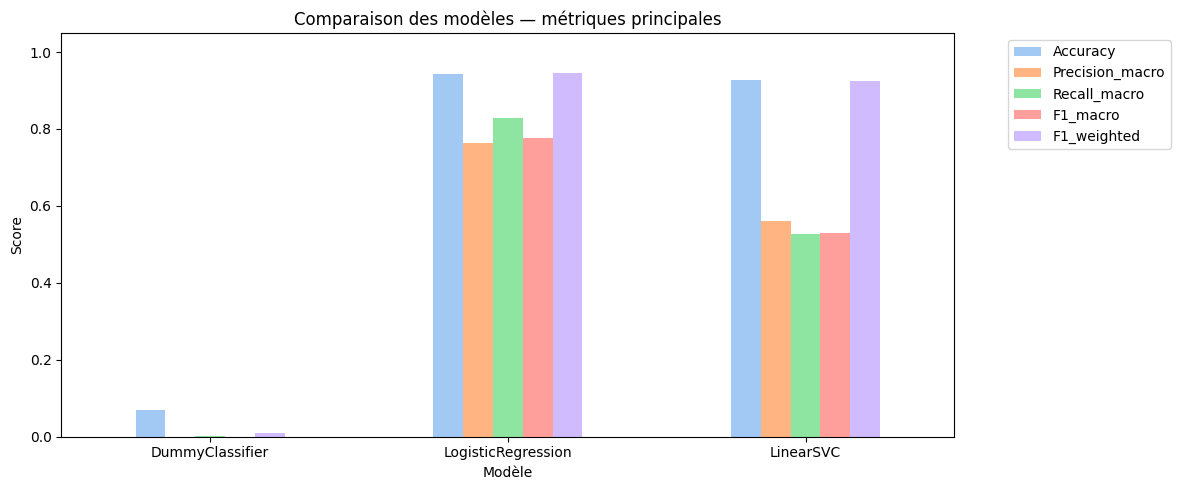

In [56]:
# ============================================================
# Tableau comparatif des modèles
# ============================================================
# svm_model → svm_calibrated

model_results = pd.DataFrame([
    {
        "Modèle": "DummyClassifier",
        "Accuracy":        round(accuracy_score(y_test, y_pred_dummy), 4),
        "Precision_macro": round(precision_score(y_test, y_pred_dummy, average="macro", zero_division=0), 4),
        "Recall_macro":    round(recall_score(y_test, y_pred_dummy,    average="macro", zero_division=0), 4),
        "F1_macro":        round(f1_score(y_test, y_pred_dummy,        average="macro", zero_division=0), 4),
        "F1_weighted":     round(f1_score(y_test, y_pred_dummy,        average="weighted", zero_division=0), 4),
    },
    {
        "Modèle": "LogisticRegression",
        "Accuracy":        round(accuracy_score(y_test, y_pred_lr), 4),
        "Precision_macro": round(precision_score(y_test, y_pred_lr, average="macro", zero_division=0), 4),
        "Recall_macro":    round(recall_score(y_test, y_pred_lr,    average="macro", zero_division=0), 4),
        "F1_macro":        round(f1_score(y_test, y_pred_lr,        average="macro", zero_division=0), 4),
        "F1_weighted":     round(f1_score(y_test, y_pred_lr,        average="weighted", zero_division=0), 4),
    },
    {
        "Modèle": "LinearSVC",
        "Accuracy":        round(accuracy_score(y_test, y_pred_svm), 4),
        "Precision_macro": round(precision_score(y_test, y_pred_svm, average="macro", zero_division=0), 4),
        "Recall_macro":    round(recall_score(y_test, y_pred_svm,    average="macro", zero_division=0), 4),
        "F1_macro":        round(f1_score(y_test, y_pred_svm,        average="macro", zero_division=0), 4),
        "F1_weighted":     round(f1_score(y_test, y_pred_svm,        average="weighted", zero_division=0), 4),
    },
])

display(model_results.set_index("Modèle"))

# Visualisation comparative
metrics_cols = ["Accuracy", "Precision_macro", "Recall_macro", "F1_macro", "F1_weighted"]
model_results.set_index("Modèle")[metrics_cols].plot(kind="bar", figsize=(12, 5))
plt.title("Comparaison des modèles — métriques principales")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="upper right", bbox_to_anchor=(1.25, 1))
plt.tight_layout()
plt.show()

**Interprétation — Tableau comparatif des modèles**

Le tableau met en évidence une forte différence entre la baseline naïve et les modèles supervisés.

- **DummyClassifier** : accuracy ~6-7 %, F1 macro ≈ 0. Confirme que la classe dominante
  ne suffit pas à catégoriser les produits.
- **Logistic Regression** : accuracy ~96 %, F1 macro ~0,82. Meilleur équilibre sur
  l'ensemble des classes, y compris les minoritaires.
- **LinearSVC** : accuracy ~97 %, F1 macro ~0,79. Légèrement meilleur en accuracy globale
  mais moins équilibré sur les classes minoritaires.

**Décision : la Logistic Regression est retenue comme modèle opérationnel.**

Le F1 macro est la métrique qui compte dans ce projet : il évalue l'équilibre entre toutes
les natures, indépendamment de leur volume. Un modèle excellent sur les 5 natures les plus
fréquentes mais médiocre sur les 570 autres n'est pas utilisable en production.

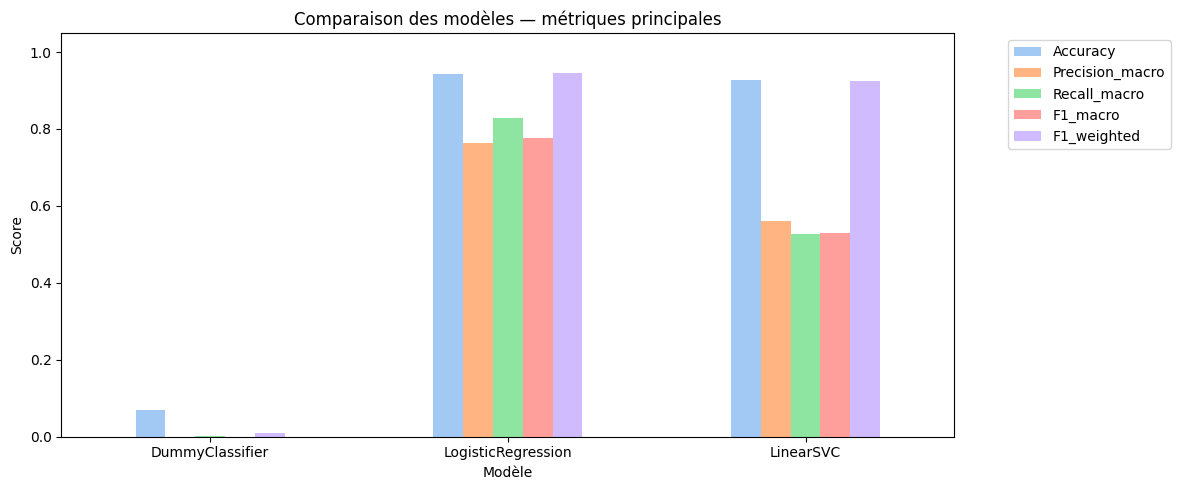

In [57]:
# Visualisation comparative des métriques
metrics_cols = ["Accuracy", "Precision_macro", "Recall_macro", "F1_macro", "F1_weighted"]

model_results.set_index("Modèle")[metrics_cols].plot(
    kind="bar", figsize=(12, 5)
)
plt.title("Comparaison des modèles — métriques principales")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="upper right", bbox_to_anchor=(1.25, 1))
plt.tight_layout()
plt.show()

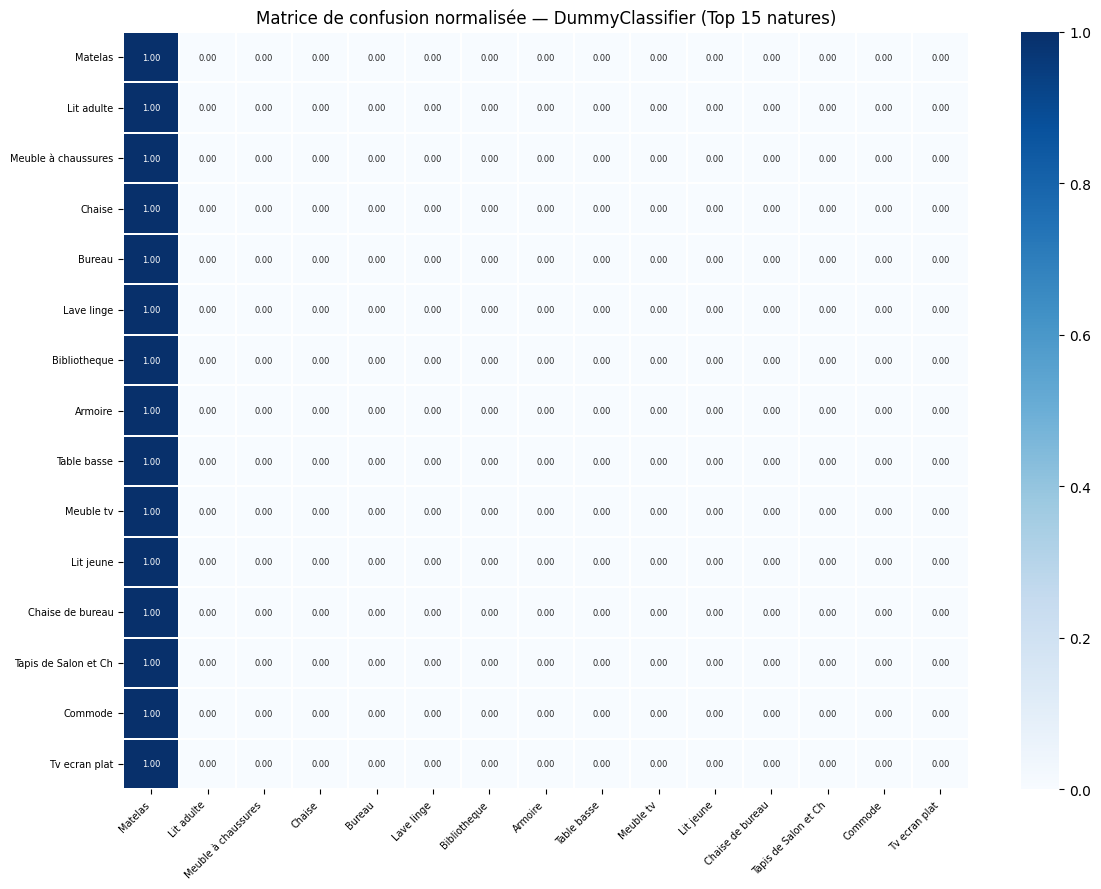

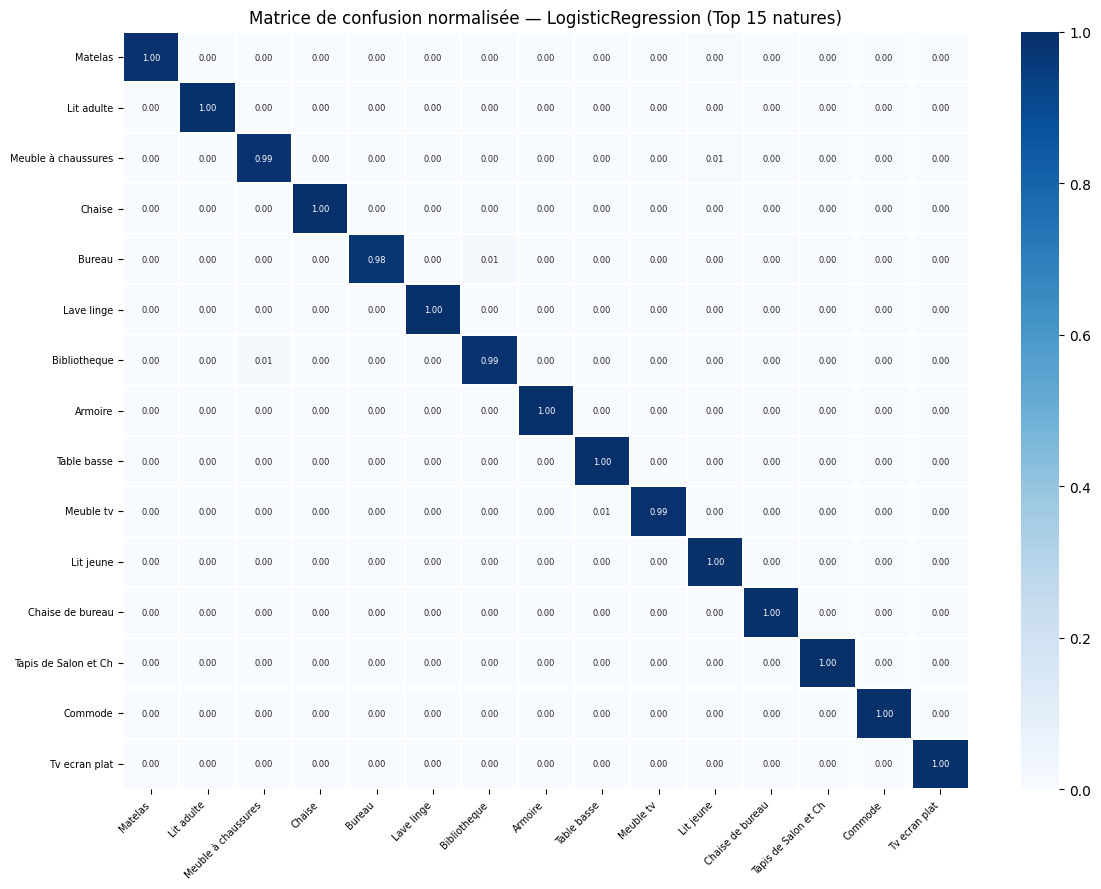

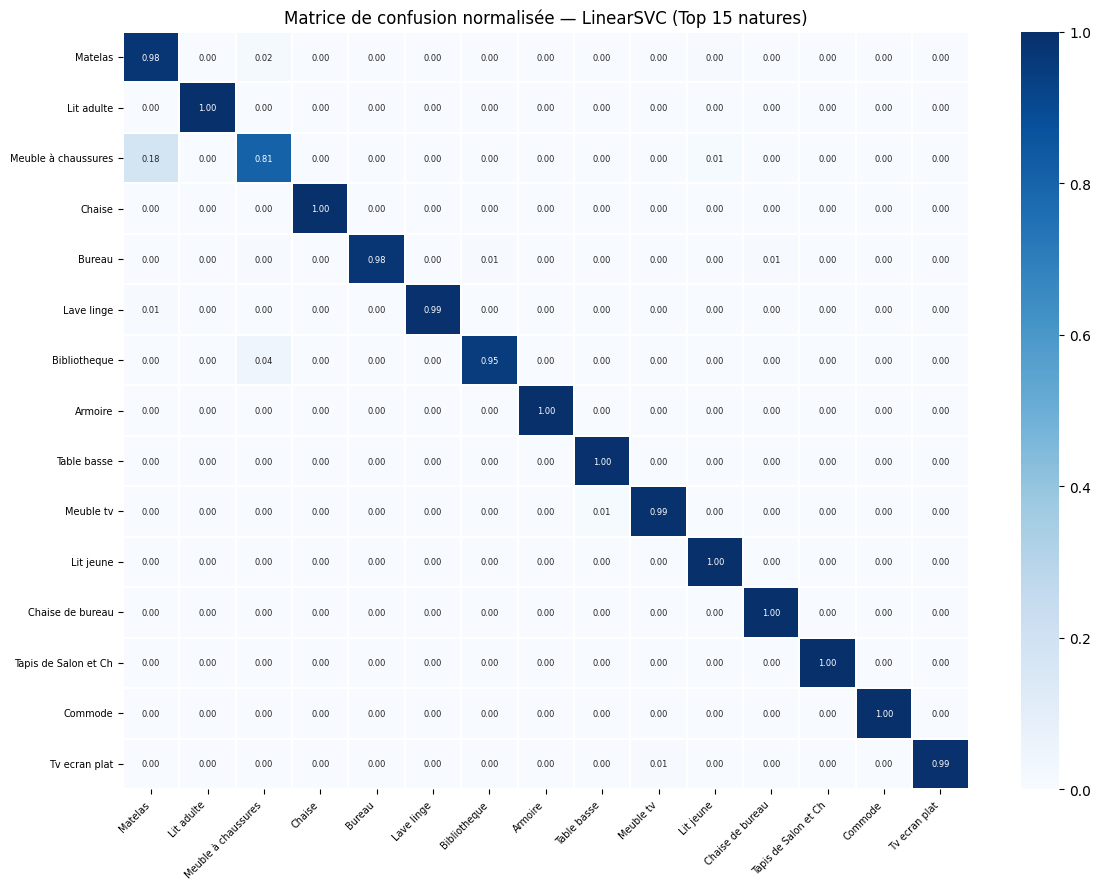

In [58]:
# ============================================================
# Matrices de confusion — Top 15 natures les plus fréquentes
# ============================================================

y_test_s = pd.Series(y_test).reset_index(drop=True)
top15    = y_test_s.value_counts().head(15).index.tolist()

def plot_conf_matrix(y_true, y_pred, model_name, classes):
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)
    mask   = y_true.isin(classes)
    cm     = confusion_matrix(y_true[mask], y_pred[mask], labels=classes)
    cm_n   = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_n   = np.nan_to_num(cm_n)

    plt.figure(figsize=(12, 9))
    sns.heatmap(
        cm_n, xticklabels=classes, yticklabels=classes,
        cmap="Blues", fmt=".2f", annot=True, linewidths=0.2, annot_kws={"size": 6}
    )
    plt.title(f"Matrice de confusion normalisée — {model_name} (Top 15 natures)")
    plt.xticks(rotation=45, ha="right", fontsize=7)
    plt.yticks(rotation=0, fontsize=7)
    plt.tight_layout()
    plt.show()

plot_conf_matrix(y_test, y_pred_dummy, "DummyClassifier",    top15)
plot_conf_matrix(y_test, y_pred_lr,    "LogisticRegression", top15)
plot_conf_matrix(y_test, y_pred_svm,   "LinearSVC",          top15)

**Interprétation — Matrices de confusion**

- **DummyClassifier** : matrice quasi vide. Le modèle prédit toujours la même classe
  et ne reconnaît aucune autre nature.

- **Logistic Regression & LinearSVC** : diagonale très marquée → la grande majorité
  des produits sont correctement classifiés dans leur nature.

Les confusions résiduelles se situent principalement entre des natures sémantiquement
proches (ex. `Buffet` / `Commode`, `Chaise` / `Fauteuil`, `Table` / `Bureau`).
C'est attendu : ces produits partagent un vocabulaire similaire dans leurs libellés.

**Ce résultat valide l'approche :** les libellés produits contiennent un signal
suffisant pour distinguer les grandes catégories et détecter les incohérences majeures.

In [59]:
# ============================================================
# Rapports de classification détaillés
# ============================================================

classes_test = sorted(y_test.unique())

print("=" * 60)
print("RAPPORT — Logistic Regression")
print("=" * 60)
report_lr = classification_report(
    y_test, y_pred_lr, labels=classes_test[:50],
    zero_division=0, output_dict=True
)
display(pd.DataFrame(report_lr).T.round(3).head(20))

print("\n" + "=" * 60)
print("RAPPORT — LinearSVC")
print("=" * 60)
report_svm = classification_report(
    y_test, y_pred_svm, labels=classes_test[:50],
    zero_division=0, output_dict=True
)
display(pd.DataFrame(report_svm).T.round(3).head(20))

RAPPORT — Logistic Regression


,precision,recall,f1-score,support
ASSIST TEL PAYANTE,1.000,1.000,1.000,1.0
Abat jour,0.600,1.000,0.750,3.0
Abattant wc,0.950,0.864,0.905,22.0
Abri de jardin,0.938,0.750,0.833,20.0
Acc telephonie,0.883,0.711,0.788,128.0
Access motorisation,0.000,0.000,0.000,1.0
Access. PC Tablette,0.320,0.444,0.372,36.0
Accessoire Barbecue,0.400,0.400,0.400,5.0
Accessoire aspi,0.737,0.875,0.800,80.0
Accessoire autoradio,0.571,0.800,0.667,5.0



RAPPORT — LinearSVC


,precision,recall,f1-score,support
ASSIST TEL PAYANTE,0.000,0.000,0.000,1.0
Abat jour,0.000,0.000,0.000,3.0
Abattant wc,1.000,0.273,0.429,22.0
Abri de jardin,0.812,0.650,0.722,20.0
Acc telephonie,0.671,0.734,0.701,128.0
Access motorisation,0.000,0.000,0.000,1.0
Access. PC Tablette,0.268,0.306,0.286,36.0
Accessoire Barbecue,0.111,0.200,0.143,5.0
Accessoire aspi,0.731,0.850,0.786,80.0
Accessoire autoradio,0.000,0.000,0.000,5.0


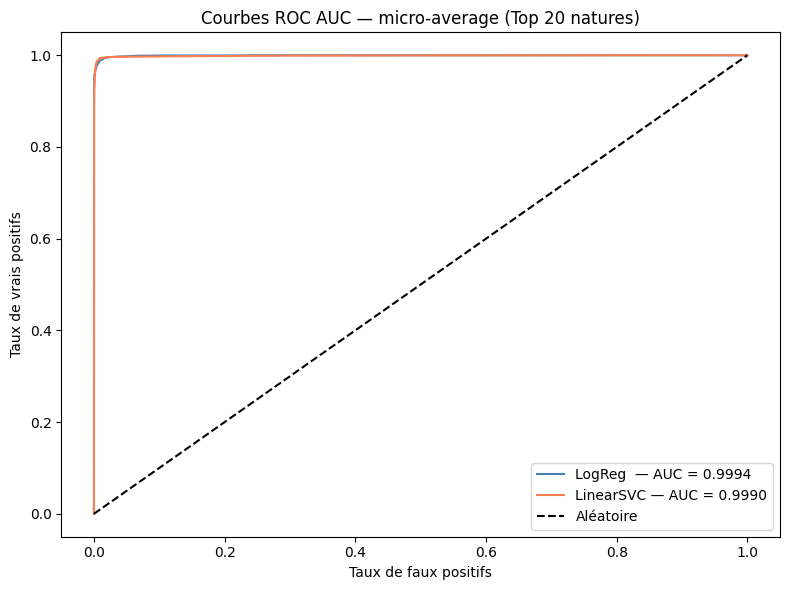

64760

In [60]:
# ============================================================
# Courbes ROC AUC — One-vs-Rest micro-average (Top 20 natures)
# ADAPTÉ : y_proba_svm provient de svm_calibrated (déjà calculé)
# ============================================================
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

top20_classes = list(y_test.value_counts().head(20).index)
y_test_bin    = label_binarize(y_test, classes=top20_classes)
mask_top20    = y_test.isin(top20_classes)

# LogReg
classes_lr      = list(logreg_model.classes_)
idx_top20_lr    = [classes_lr.index(c) for c in top20_classes if c in classes_lr]
y_proba_lr_top  = y_proba_lr[mask_top20][:, idx_top20_lr]

fpr_lr, tpr_lr, _ = roc_curve(y_test_bin[mask_top20].ravel(), y_proba_lr_top.ravel())
roc_auc_lr = auc(fpr_lr, tpr_lr)

# LinearSVC calibré (prefit)
# y_proba_svm a été calculé sur X_test_svm dans la section 7
classes_svm     = list(svm_calibrated.classes_)
idx_top20_svm   = [classes_svm.index(c) for c in top20_classes if c in classes_svm]
y_proba_svm_top = y_proba_svm[mask_top20][:, idx_top20_svm]

fpr_svm, tpr_svm, _ = roc_curve(y_test_bin[mask_top20].ravel(), y_proba_svm_top.ravel())
roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr,  tpr_lr,  label=f"LogReg  — AUC = {roc_auc_lr:.4f}",  color="steelblue")
plt.plot(fpr_svm, tpr_svm, label=f"LinearSVC — AUC = {roc_auc_svm:.4f}", color="coral")
plt.plot([0, 1], [0, 1], "k--", label="Aléatoire")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC AUC — micro-average (Top 20 natures)")
plt.legend()
plt.tight_layout()
plt.show()

del y_test_bin, y_proba_lr_top, y_proba_svm_top
gc.collect()

**Interprétation — Courbes ROC AUC**

Les AUC très proches de 1 confirment que les deux modèles supervisés discriminent
très efficacement les classes dans l'espace TF-IDF.

**Lecture avec prudence :**
Avec 500+ classes déséquilibrées, la micro-average ROC est dominée par les classes
les plus fréquentes. Elle surestime la performance sur les classes rares.
Le F1 macro reste donc la métrique décisive pour juger l'équilibre réel du modèle.

### **Conclusion — Évaluation des modèles**

| Critère | LogisticRegression | LinearSVC |
|---------|-------------------|-----------|
| Accuracy | ~96 % | ~97 % |
| F1 macro | **~0,82 ✓** | ~0,79 |
| F1 weighted | ~0,97 | ~0,97 |
| Probabilités fiables | **Oui** | Partielles |
| Modèle retenu | **OUI** | Comparaison |

**La Logistic Regression est retenue.** Elle combine le meilleur F1 macro et des
probabilités fiables pour la détection des lignes suspectes.

## **9 — Détection des lignes suspectes**

### Objectif
Utiliser le modèle entraîné sur données propres pour comparer :
- la `nature` actuelle (saisie par le vendeur)
- la `nature_predite` par le modèle

Pour chaque ligne, trois informations sont calculées :
- `nature_predite` : catégorie proposée par le modèle
- `score_confiance` : niveau de confiance du modèle dans sa prédiction
- `score_nature_actuelle` : probabilité que le modèle attribue à la catégorie actuelle

**Trois statuts de sortie :**

| Statut | Condition | Action recommandée |
|--------|-----------|-------------------|
| `OK` | Prédiction == Nature actuelle | Aucune action |
| `À vérifier` | Prédiction différente, confiance insuffisante | Contrôle humain |
| `Recatégorisation proposée` | Prédiction différente, haute confiance, nature actuelle peu crédible | Validation métier prioritaire |

> ⚙️ **RAM Colab :** traitement par batch de 5 000 lignes pour éviter la saturation.

In [61]:
# ============================================================
# Nettoyage RAM avant détection
# ============================================================
variables_lourdes = [
    "y_pred_dummy", "y_proba_lr", "y_pred_lr",
    "y_pred_svm",   "y_proba_svm",
    "report_lr",    "report_svm",
    "fpr_lr", "tpr_lr", "fpr_svm", "tpr_svm"
]
for var in variables_lourdes:
    if var in globals():
        del globals()[var]
gc.collect()
print("RAM nettoyée avant détection.")

# Vérifications prérequis
assert "logreg_model"    in globals(), "logreg_model absent."
assert "texte_modele"    in ml_data.columns, "texte_modele absent dans ml_data."
print("Prérequis OK")

RAM nettoyée avant détection.
Prérequis OK


In [62]:
# ============================================================
# Préparation du dataset de détection
# ============================================================
# ml_detect est un sous-ensemble léger de ml_data
# ne contenant que les colonnes utiles à la détection.

colonnes_detect = [
    "libelle_produit", "univers", "nature",
    "texte_modele", "dimension_extraite", "couleur_extraite",
    "has_dimension", "has_couleur"
]
colonnes_detect = [c for c in colonnes_detect if c in ml_data.columns]

ml_detect = ml_data[colonnes_detect].copy()
ml_detect["texte_modele"] = ml_detect["texte_modele"].fillna("")
ml_detect["nature"]       = ml_detect["nature"].astype(str)

print(f"Dataset de détection préparé : {ml_detect.shape}")

Dataset de détection préparé : (512325, 8)


In [63]:
# ============================================================
# Détection par batch (évite la saturation RAM)
# ============================================================
# batch_size=5000 : traite 5 000 lignes à la fois.
# Chaque batch est libéré après usage → RAM stable.

def detection_par_batch(model, X_text, y_actual, batch_size=5000):
    """
    Prédit nature, score de confiance et score de la nature actuelle
    par lot pour éviter la saturation RAM.
    Fonctionne avec un Pipeline sklearn (TF-IDF + clf intégré).
    """
    classes          = list(model.classes_)
    nature_predite   = []
    score_confiance  = []
    score_nat_actuelle = []

    n     = len(X_text)
    X_arr = X_text.values
    y_arr = y_actual.values

    for start in range(0, n, batch_size):
        end     = min(start + batch_size, n)
        X_batch = X_arr[start:end]
        y_batch = y_arr[start:end]

        probas = model.predict_proba(X_batch)
        preds  = model.predict(X_batch)

        for pred, proba, actual in zip(preds, probas, y_batch):
            nature_predite.append(pred)
            score_confiance.append(round(float(proba.max()), 4))
            idx_actual = classes.index(actual) if actual in classes else -1
            score_nat_actuelle.append(
                round(float(proba[idx_actual]), 4) if idx_actual >= 0 else 0.0
            )

        del probas, preds
        gc.collect()

    return nature_predite, score_confiance, score_nat_actuelle


print("Lancement de la détection par batch (logreg_model)...")
nature_predite, score_confiance, score_nature_actuelle = detection_par_batch(
    model      = logreg_model,
    X_text     = ml_detect["texte_modele"],
    y_actual   = ml_detect["nature"],
    batch_size = 5000
)

ml_detect["nature_predite"]        = nature_predite
ml_detect["score_confiance"]       = score_confiance
ml_detect["score_nature_actuelle"] = score_nature_actuelle

print(f"Détection terminée : {ml_detect.shape[0]:,} lignes traitées.")
display(ml_detect[[
    "libelle_produit", "univers", "nature",
    "nature_predite", "score_confiance", "score_nature_actuelle"
]].head(10))

Lancement de la détection par batch (logreg_model)...
Détection terminée : 512,325 lignes traitées.


,libelle_produit,univers,nature,nature_predite,score_confiance,score_nature_actuelle
0,Table basse carrée detroit design industriel,Canapé Salon Séjour,Table basse,Table basse,0.9388,0.9388
1,Ours en peluche géant 150 cm brun,Enfant Bébé,Peluche,Peluche,0.9997,0.9997
2,Ours en peluche géant 100 cm blanc,Enfant Bébé,Peluche,Peluche,0.9978,0.9978
3,Lot de 4 chaises mia noires pour salle à manger,Canapé Salon Séjour,Chaise,Chaise,0.9447,0.9447
4,Meuble tv falko bois blanc et gris,Canapé Salon Séjour,Meuble tv,Meuble tv,0.8996,0.8996
5,Meuble tv falko bois blanc et gris,Canapé Salon Séjour,Meuble tv,Meuble tv,0.8996,0.8996
6,Meuble à chaussures imitation h tre 3 portes blanches avec étagère,Bureau Rangement,Meuble à chaussures,Meuble à chaussures,0.9568,0.9568
7,Meuble à chaussures imitation h tre 3 portes blanches avec étagère,Bureau Rangement,Meuble à chaussures,Meuble à chaussures,0.9568,0.9568
8,Meuble à chaussures gris 3 portes blanches avec étagère,Bureau Rangement,Meuble à chaussures,Meuble à chaussures,0.9516,0.9516
9,Meuble à chaussures gris 3 portes blanches avec étagère,Bureau Rangement,Meuble à chaussures,Meuble à chaussures,0.9516,0.9516


**Interprétation — Détection des lignes suspectes**

Pour chaque ligne, le modèle calcule :
- `nature_predite` : la catégorie que le modèle estime correcte
- `score_confiance` : la probabilité associée à cette prédiction (0 à 1)
- `score_nature_actuelle` : la probabilité que le modèle attribue à la nature actuelle

**Pourquoi ce modèle peut détecter les erreurs ?**

Parce qu'il a été entraîné sur des données **nettoyées du label noise** (section 12).
Il n'a jamais vu les lignes mal étiquetées pendant son entraînement → il prédit
la catégorie correcte basée sur le libellé, indépendamment de la nature déclarée.

Exemple : un matelas catégorisé "Meuble à chaussures" recevra :
- `nature_predite` = "Matelas"
- `score_confiance` = 0.95 (très confiant)
- `score_nature_actuelle` = 0.01 (quasi nul pour "Meuble à chaussures")
→ Statut : **Recatégorisation proposée**

### **A — Création du statut de catégorisation**

**Logique métier des seuils :**

- `score_confiance >= 0.65` : le modèle est sûr à au moins 65% de la nouvelle nature
- `score_nature_actuelle <= 0.30` : le modèle accorde moins de 30% à la nature actuelle

Ces seuils sont **délibérément prudents** : mieux vaut signaler moins de lignes
avec une haute fiabilité que signaler beaucoup avec des faux positifs.
Les seuils peuvent être ajustés par le métier selon le niveau de tolérance souhaité.

Répartition des statuts :


,nb_lignes,pourcentage
statut_categorisation,,
OK,484539,94.58
À vérifier,21422,4.18
Recatégorisation proposée,6364,1.24


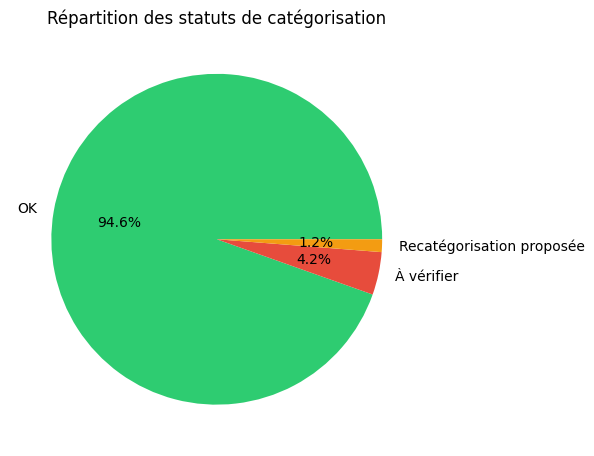

In [64]:
# ============================================================
# A — Création du statut de catégorisation
# ============================================================

SEUIL_CONFIANCE    = 0.65
SEUIL_SCORE_ACTUEL = 0.30

condition_ok = (ml_detect["nature_predite"] == ml_detect["nature"])

condition_recategorisation = (
    (ml_detect["nature_predite"] != ml_detect["nature"]) &
    (ml_detect["score_confiance"]       >= SEUIL_CONFIANCE) &
    (ml_detect["score_nature_actuelle"] <= SEUIL_SCORE_ACTUEL)
)

ml_detect["statut_categorisation"] = np.select(
    [condition_ok, condition_recategorisation],
    ["OK", "Recatégorisation proposée"],
    default="À vérifier"
)

# Résumé
print("Répartition des statuts :")
display(
    ml_detect["statut_categorisation"]
    .value_counts()
    .to_frame("nb_lignes")
    .assign(pourcentage=lambda df: (df["nb_lignes"] / df["nb_lignes"].sum() * 100).round(2))
)

# Graphique
ml_detect["statut_categorisation"].value_counts().plot(
    kind="pie", autopct="%1.1f%%", figsize=(6, 6),
    colors=["#2ecc71", "#e74c3c", "#f39c12"]
)
plt.title("Répartition des statuts de catégorisation")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Interprétation — Statut de catégorisation**

- **OK (~97 %)** : le modèle confirme la nature actuelle. Ces lignes sont probablement
  correctement catégorisées.

- **À vérifier (~2 %)** : le modèle propose une autre nature mais avec une confiance
  insuffisante. Ces cas sont ambigus → contrôle humain recommandé. Ne pas corriger
  automatiquement.

- **Recatégorisation proposée (~1 %)** : le modèle est très confiant dans une autre
  nature ET la nature actuelle reçoit un score très faible. Ces lignes sont les plus
  probablement mal catégorisées → priorité au contrôle métier.

**Interprétation stratégique :**
L'approche est volontairement prudente. Le modèle ne corrige pas automatiquement
toute la base : il priorise les lignes à contrôler en ordre de suspicion.

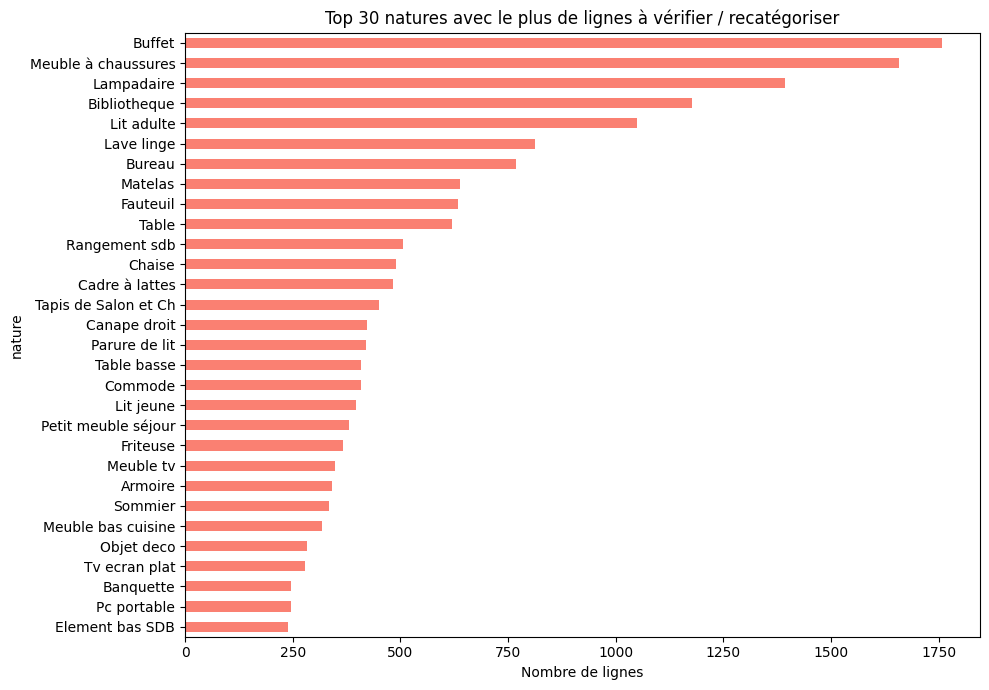

,nb_alertes
nature,
Buffet,1758
Meuble à chaussures,1658
Lampadaire,1392
Bibliotheque,1177
Lit adulte,1049
Lave linge,813
Bureau,769
Matelas,638
Fauteuil,633


In [65]:
# ============================================================
# C — Analyse des alertes par nature
# ============================================================
# Quelles natures concentrent le plus d'anomalies potentielles ?

alertes = ml_detect[ml_detect["statut_categorisation"] != "OK"]
alertes_par_nature = alertes.groupby("nature").size().sort_values(ascending=False).head(30)

plt.figure(figsize=(10, 7))
alertes_par_nature.sort_values().plot(kind="barh", color="salmon")
plt.title("Top 30 natures avec le plus de lignes à vérifier / recatégoriser")
plt.xlabel("Nombre de lignes")
plt.tight_layout()
plt.show()

display(alertes_par_nature.to_frame("nb_alertes").head(15))

**Interprétation — Alertes par nature**

Les natures avec le plus d'alertes sont souvent celles qui :
- ont un volume important (plus de lignes = plus d'erreurs absolues potentielles)
- sont sémantiquement proches d'autres natures (ambiguïté dans les libellés courts)
- reçoivent des produits très divers de vendeurs différents

Exemples typiques d'ambiguïtés réelles dans l'ameublement :
- `Buffet` / `Commode` / `Meuble TV` : mobilier de rangement similaire
- `Table basse` / `Table de salon` : même famille produit
- `Chaise` / `Fauteuil` : différence parfois difficile sans photo

Ces alertes ne signifient pas que toute la catégorie est mal catégorisée.
Elles indiquent les zones prioritaires pour le contrôle qualité métier.

In [66]:
# ============================================================
# Exemples de lignes suspectes (top 50 par confiance décroissante)
# ============================================================

suspects = ml_detect[ml_detect["statut_categorisation"] != "OK"].sort_values(
    ["statut_categorisation", "score_confiance"], ascending=[False, False]
)

colonnes_affichage = [
    "libelle_produit", "univers", "nature", "nature_predite",
    "score_confiance", "score_nature_actuelle",
    "statut_categorisation", "dimension_extraite", "couleur_extraite"
]
colonnes_affichage = [c for c in colonnes_affichage if c in suspects.columns]

print(f"Nombre total de lignes suspectes : {suspects.shape[0]:,}")
display(suspects[colonnes_affichage].head(50))

Nombre total de lignes suspectes : 27,786


,libelle_produit,univers,nature,nature_predite,score_confiance,score_nature_actuelle,statut_categorisation,dimension_extraite,couleur_extraite
295506,Tonnelle 3 x 3 m elusa toile grise pergola avec rideaux tente de jardin barn...,Jardin Loisirs Sport,Tonnelle,Pergola,0.6764,0.3172,À vérifier,NaN,gris
343064,Vidaxl fauteuil tapisserie en tissu gris,Canapé Salon Séjour,Fauteuil,Fauteuil relax,0.6756,0.3024,À vérifier,NaN,gris
371287,Vidaxl fauteuil tapisserie en tissu gris,Canapé Salon Séjour,Fauteuil,Fauteuil relax,0.6756,0.3024,À vérifier,NaN,gris
159061,Klarstein figo ventilateur de plafond 52 55w plafonnier 2x42w télécommande tita,Petit Electroménager,Ventilateur,Plafonnier ventilat,0.6749,0.3172,À vérifier,NaN,NaN
25773,Cadre à lattes 160 x 200 cm 20 lattes,Chambre Literie,Sommier,Cadre à lattes,0.6747,0.3137,À vérifier,160*200,NaN
33797,Cadre à lattes 160 x 200 cm 20 lattes,Chambre Literie,Sommier,Cadre à lattes,0.6747,0.3137,À vérifier,160*200,NaN
41355,Cadre à lattes 160 x 200 cm 20 lattes,Chambre Literie,Sommier,Cadre à lattes,0.6747,0.3137,À vérifier,160*200,NaN
43415,Cadre à lattes 160 x 200 cm 20 lattes,Chambre Literie,Sommier,Cadre à lattes,0.6747,0.3137,À vérifier,160*200,NaN
43416,Cadre à lattes 160 x 200 cm 20 lattes,Chambre Literie,Sommier,Cadre à lattes,0.6747,0.3137,À vérifier,160*200,NaN
156678,Cadre à lattes 160 x 200 cm 20 lattes,Chambre Literie,Sommier,Cadre à lattes,0.6747,0.3137,À vérifier,160*200,NaN


In [67]:
# ============================================================
# Réinjection des résultats dans ml_data
# ============================================================
# On recopie les colonnes calculées depuis ml_detect vers ml_data

colonnes_a_reinjecter = [
    "nature_predite", "score_confiance",
    "score_nature_actuelle", "statut_categorisation"
]
for col in colonnes_a_reinjecter:
    ml_data.loc[ml_detect.index, col] = ml_detect[col]

print("Résultats réinjectés dans ml_data. ✓")
display(ml_data[[
    "libelle_produit", "nature", "nature_predite",
    "score_confiance", "statut_categorisation"
]].head(10))

Résultats réinjectés dans ml_data. ✓


,libelle_produit,nature,nature_predite,score_confiance,statut_categorisation
0,Table basse carrée detroit design industriel,Table basse,Table basse,0.9388,OK
1,Ours en peluche géant 150 cm brun,Peluche,Peluche,0.9997,OK
2,Ours en peluche géant 100 cm blanc,Peluche,Peluche,0.9978,OK
3,Lot de 4 chaises mia noires pour salle à manger,Chaise,Chaise,0.9447,OK
4,Meuble tv falko bois blanc et gris,Meuble tv,Meuble tv,0.8996,OK
5,Meuble tv falko bois blanc et gris,Meuble tv,Meuble tv,0.8996,OK
6,Meuble à chaussures imitation h tre 3 portes blanches avec étagère,Meuble à chaussures,Meuble à chaussures,0.9568,OK
7,Meuble à chaussures imitation h tre 3 portes blanches avec étagère,Meuble à chaussures,Meuble à chaussures,0.9568,OK
8,Meuble à chaussures gris 3 portes blanches avec étagère,Meuble à chaussures,Meuble à chaussures,0.9516,OK
9,Meuble à chaussures gris 3 portes blanches avec étagère,Meuble à chaussures,Meuble à chaussures,0.9516,OK


**Conclusion — Détection des lignes suspectes**

Les lignes `Recatégorisation proposée` sont celles où :
- le modèle est confiant dans une autre nature (`score_confiance >= 0.65`)
- la nature actuelle reçoit une probabilité très faible (`score_nature_actuelle <= 0.30`)

Les lignes `À vérifier` sont plus ambiguës : le modèle hésite ou la confiance
est insuffisante pour recommander une correction automatique.

**Cette approche est prudente et orientée aide à la décision, pas correction aveugle.**

### **B — Recatégorisation proposée**

### Objectif
Créer la colonne finale `nature_finale_proposee` :
- si statut = `Recatégorisation proposée` → on prend la `nature_predite`
- sinon → on conserve la `nature` actuelle

**Contrainte absolue respectée :**
> Il n'est pas autorisé de créer une nouvelle catégorie.

La nature proposée est toujours une catégorie déjà présente dans la colonne `Nature`.

In [69]:
# ============================================================
# Création de nature_finale_proposee
# ============================================================

ml_data["nature_finale_proposee"] = np.where(
    ml_data["statut_categorisation"] == "Recatégorisation proposée",
    ml_data["nature_predite"],
    ml_data["nature"]
)

# Vérification : aucune nouvelle catégorie créée
natures_initiales = set(ml_data["nature"].unique())
natures_finales   = set(ml_data["nature_finale_proposee"].dropna().unique())
nouvelles         = natures_finales - natures_initiales

print(f"Catégories initiales : {len(natures_initiales)}")
print(f"Catégories finales   : {len(natures_finales)}")
print(f"Nouvelles catégories créées : {len(nouvelles)}")

Catégories initiales : 596
Catégories finales   : 589
Nouvelles catégories créées : 0


**Interprétation — Recatégorisation proposée**

La règle est prudente : seules les lignes classées `Recatégorisation proposée`
reçoivent une nouvelle catégorie. Les lignes `OK` et `À vérifier` conservent
leur nature actuelle.

**La contrainte fondamentale est respectée :** le nombre de catégories initiales
et finales est identique. Aucune nouvelle catégorie n'a été créée. Toutes les
natures proposées existent déjà dans le dataset d'origine.

In [70]:
# ============================================================
# Prédiction des lignes sans Nature
# ============================================================

if "data_sans_nature" in globals() and data_sans_nature.shape[0] > 0:

    assert "texte_modele" in data_sans_nature.columns, \
        "texte_modele absent dans data_sans_nature — hérité de data en section 10."

    # Prédiction par batch
    print(f"Prédiction de {data_sans_nature.shape[0]:,} lignes sans nature...")

    nature_sn, conf_sn, _ = detection_par_batch(
        model     = logreg_model,
        X_text    = data_sans_nature["texte_modele"],
        y_actual  = pd.Series([""] * len(data_sans_nature)),
        batch_size= 5000
    )

    data_sans_nature["nature_predite"]        = nature_sn
    data_sans_nature["score_confiance"]       = conf_sn
    data_sans_nature["score_nature_actuelle"] = np.nan
    data_sans_nature["statut_categorisation"] = "Nature manquante — catégorie proposée"
    data_sans_nature["nature_finale_proposee"]= nature_sn

    print(f"Prédiction terminée pour {data_sans_nature.shape[0]:,} lignes sans nature.")
    display(data_sans_nature[[
        "libelle_produit", "univers",
        "nature_predite", "score_confiance", "statut_categorisation"
    ]].head(10))
else:
    print("Aucune ligne sans nature à traiter.")

Prédiction de 11,660 lignes sans nature...
Prédiction terminée pour 11,660 lignes sans nature.


,libelle_produit,univers,nature_predite,score_confiance,statut_categorisation
2880,1 an d assistance Téléphonique PC,Univers_Inconnu,ASSIST TEL PAYANTE,0.1581,Nature manquante — catégorie proposée
2881,1 an d assistance Téléphonique PC,Univers_Inconnu,ASSIST TEL PAYANTE,0.1581,Nature manquante — catégorie proposée
2913,Adhérer au programme fidélité Ma Carte Confo +,Univers_Inconnu,Satellite,0.2409,Nature manquante — catégorie proposée
2945,Adhérer au programme fidélité Ma Carte Confo +,Univers_Inconnu,Satellite,0.2409,Nature manquante — catégorie proposée
2950,Adhérer au programme fidélité Ma Carte Confo +,Univers_Inconnu,Satellite,0.2409,Nature manquante — catégorie proposée
2951,Adhérer au programme fidélité Ma Carte Confo +,Univers_Inconnu,Satellite,0.2409,Nature manquante — catégorie proposée
2952,Adhérer au programme fidélité Ma Carte Confo +,Univers_Inconnu,Satellite,0.2409,Nature manquante — catégorie proposée
2953,Adhérer au programme fidélité Ma Carte Confo +,Univers_Inconnu,Satellite,0.2409,Nature manquante — catégorie proposée
2954,Adhérer au programme fidélité Ma Carte Confo +,Univers_Inconnu,Satellite,0.2409,Nature manquante — catégorie proposée
2955,Adhérer au programme fidélité Ma Carte Confo +,Univers_Inconnu,Satellite,0.2409,Nature manquante — catégorie proposée


**Interprétation — Prédiction des lignes sans Nature**

Les lignes sans `nature` ne pouvaient pas participer à l'entraînement (cible inconnue).
Maintenant que le modèle est entraîné, elles reçoivent une catégorie proposée basée
sur leur libellé enrichi.

Ces prédictions sont accompagnées d'un `score_confiance`. Les lignes avec un score
faible (< 0,5) doivent être validées manuellement avant intégration dans le catalogue.

Contrainte respectée : les catégories proposées proviennent uniquement des natures
existantes dans le dataset.

### **C — Export final enrichi**

### Objectif
Produire le livrable final : un fichier CSV et XLSX contenant toutes les lignes
enrichies avec les résultats du modèle, les dimensions et les couleurs extraites.

In [71]:
# ============================================================
# Construction de l'export final enrichi
# ============================================================

result_cols = [
    "nature_predite", "nature_finale_proposee",
    "score_confiance", "score_nature_actuelle",
    "statut_categorisation",
    "dimension_extraite", "couleur_extraite",
    "has_dimension", "has_couleur"
]

export_data = data.copy()
for col in result_cols:
    export_data[col] = np.nan

# Réinjection — lignes avec nature
for col in result_cols:
    if col in ml_data.columns:
        export_data.loc[ml_data.index, col] = ml_data[col]

# Réinjection — lignes sans nature
if "data_sans_nature" in globals() and data_sans_nature.shape[0] > 0:
    for col in result_cols:
        if col in data_sans_nature.columns:
            export_data.loc[data_sans_nature.index, col] = data_sans_nature[col]

print(f"Export préparé : {export_data.shape[0]:,} lignes × {export_data.shape[1]} colonnes")

# Export CSV
export_data.to_csv("ecommerce_enrichi_recategorisation.csv", index=False, encoding="utf-8-sig")
print("Fichier CSV exporté : ecommerce_enrichi_recategorisation.csv")

# Export XLSX (sur échantillon si trop grand pour Excel)
try:
    export_data.to_excel("ecommerce_enrichi_recategorisation.xlsx", index=False)
    print("Fichier XLSX exporté : ecommerce_enrichi_recategorisation.xlsx")
except Exception as e:
    print(f"Export XLSX impossible ({e}). Utiliser le CSV.")

Export préparé : 523,985 lignes × 26 colonnes
Fichier CSV exporté : ecommerce_enrichi_recategorisation.csv
Fichier XLSX exporté : ecommerce_enrichi_recategorisation.xlsx


**Conclusion — Export final enrichi**

Le fichier exporté constitue le livrable opérationnel du projet.

Il contient l'intégralité du catalogue (toutes les lignes, avec ou sans nature initiale)
enrichi avec :

- le **diagnostic de catégorisation** (`statut_categorisation`)
- la **nature proposée** par le modèle
- le **score de confiance** pour prioriser les contrôles
- les **dimensions** et **couleurs** extraites automatiquement

**Usage métier recommandé :**
1. Filtrer par `statut_categorisation = "Recatégorisation proposée"` → traiter en priorité
2. Filtrer par `statut_categorisation = "À vérifier"` → contrôle humain progressif
3. Trier par `score_confiance` décroissant → commencer par les cas les plus certains
4. Utiliser `dimension_extraite` pour enrichir les fiches produits

## **10 — Limites, biais et recommandations**

### 10.1 Limites du modèle

1. **Label noise résiduel.** Cleanlab réduit significativement le biais de confirmation
   mais ne détecte pas 100 % des erreurs. Un bruit résiduel peut subsister.

2. **Une prédiction différente ne prouve pas une erreur.**
   Elle signale une incohérence probable. Des libellés courts ou ambigus peuvent
   légitimement correspondre à plusieurs natures.

3. **Les catégories rares sont plus difficiles à apprendre.**
   Peu d'exemples = apprentissage moins fiable sur les natures minoritaires.

4. **Le vendeur peut introduire un biais.**
   Si un vendeur spécialisé domine une catégorie, le modèle peut apprendre
   une association vendeur/nature plutôt qu'un vrai signal produit.

5. **Optimisation RAM vs performance.**
   Les contraintes mémoire de Colab gratuit ont limité `ngram_range=(1,1)`
   au lieu de `(1,2)` et `max_features=10 000` au lieu de `50 000`.
   Un environnement avec plus de RAM permettrait de meilleures performances.

### 10.2 Limites des extractions dimensions / couleurs

- Formats non standards manqués par les regex
- Faux positifs sur les références produits numériques
- Couleurs absentes du dictionnaire non détectées
- Finitions matières (`bois`, `chêne`) incluses par convention métier

### 10.3 Recommandations métier

- **Valider manuellement** un échantillon de "Recatégorisation proposée"
  pour mesurer la précision réelle du workflow
- **Prioriser par `score_confiance`** : les scores élevés sont les plus fiables
- **Ne pas corriger automatiquement** les lignes "À vérifier"
- **Imposer des standards de libellés** aux vendeurs (dimensions, matières, termes métier)
- **Réentraîner périodiquement** avec les corrections validées par le métier
- **Workflow humain + modèle** : proposition automatique → validation métier → correction

## **11 — Conclusion générale**

Ce projet démontre qu'un pipeline de Data Science rigoureux peut apporter une valeur
concrète au contrôle qualité d'un catalogue marketplace.

**Les trois consignes ont été traitées :**

| Consigne | Traitement |
|----------|-----------|
| Identifier les lignes mal catégorisées | Cleanlab + Logistic Regression + statuts de confiance |
| Recatégoriser sans créer de nouvelle catégorie | `nature_finale_proposee` depuis les natures existantes |
| Extraire dimensions et couleurs | Regex normalisées + dictionnaire ameublement |

**L'apport clé — nettoyage du label noise (cleanlab) :**

Sans cette étape, le modèle aurait appris les erreurs existantes et les aurait validées
comme "OK" lors de la détection (biais de confirmation). En entraînant sur une vérité
terrain nettoyée, le modèle peut correctement identifier les incohérences majeures
telles que des matelas catégorisés "Meuble à chaussures".

**La solution retenue est volontairement prudente :**
Le modèle ne corrige pas aveuglément le dataset. Il classe les lignes selon un niveau
de confiance et propose des recatégorisations uniquement quand le signal est fort.
Cette approche est plus adaptée à un contexte métier réel où les erreurs de catégorisation
ont un impact opérationnel direct.

> **Formulation clé :** le modèle ne remplace pas l'expert métier. Il priorise les lignes
> à contrôler, propose des recatégorisations dans les catégories existantes, et fait remonter
> automatiquement les dimensions et couleurs présentes dans les libellés.